In [1]:
pip install numpy pandas matplotlib seaborn pyyaml

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import os
from collections import defaultdict
import numbers
from statistics import mean
import json

In [34]:
path_to_files = '../nsight_gr_results/'

versiones = ["CS_1st", "CS_2nd", "CS_std", "CU_1st", "CU_2nd"]
moleculas = ["1aga", "1c0o", "2mjq", "8wql"]
rangos = [
    "range1", 
    "range2",
    "range3",
    "range4",
    "range5"
    ]

path_archivos = {}
path_frames = {}

for version in versiones:
    path_archivos[version] = {}
    path_frames[version] = {}
    for molecula in moleculas:
        path_archivos[version][molecula] = {}
        path_frames[version][molecula] = {}
        for rango in rangos:
            path_archivos[version][molecula][rango] = [f"{path_to_files}{version}/{molecula}/YAML/{rango}_1_analysis.yaml",
                                                       f"{path_to_files}{version}/{molecula}/YAML/{rango}_2_analysis.yaml",
                                                       f"{path_to_files}{version}/{molecula}/YAML/{rango}_3_analysis.yaml"]
            path_frames[version][molecula][rango] = f"{path_to_files}{version}/{molecula}/YAML/{rango}_frames.txt"


In [36]:
def guardar_resultados_json(resultados, nombre_archivo="resultados_analisis.json"):
    """Guarda la lista de diccionarios en un archivo JSON."""
    try:
        with open(nombre_archivo, 'w', encoding='utf-8') as f:
            # indent=4 hace que el archivo sea legible para humanos
            json.dump(resultados, f, ensure_ascii=False, indent=4)
        print(f"✅ Datos guardados exitosamente en: {nombre_archivo}")
    except Exception as e:
        print(f"❌ Error al guardar JSON: {e}")

def cargar_resultados_json(nombre_archivo="resultados_analisis.json"):
    """Lee el archivo JSON y lo devuelve como lista de Python."""
    try:
        with open(nombre_archivo, 'r', encoding='utf-8') as f:
            datos = json.load(f)
        print(f"✅ Datos cargados: {len(datos)} rangos encontrados.")
        return datos
    except Exception as e:
        print(f"❌ Error al cargar JSON: {e}")
        return []

In [4]:
def cargar_tiempos_frames(path_frames):
    """
    Lee el archivo de tiempos y devuelve una lista de listas.
    Ej: [[70.38, 70.36...], [257.35, 256.90...], ...]
    """
    bloques_tiempos = []
    try:
        with open(path_frames, 'r', encoding='utf-8') as f:
            contenido = f.read().strip()
            
        # Separamos por los guiones que indicaste
        partes = contenido.split('------')
        
        for p in partes:
            if p.strip(): # Evitar bloques vacíos
                # Convertimos cada línea en un número flotante
                tiempos = [float(linea.strip()) for linea in p.strip().splitlines() if linea.strip()]
                bloques_tiempos.append(tiempos)
                
        print(f"Se cargaron {len(bloques_tiempos)} bloques de tiempos de frames.")
        return bloques_tiempos
    except Exception as e:
        print(f"Error cargando tiempos de frames: {e}")
        return []

In [5]:
def leer_y_analizar_yaml(archivo_path):
    # 1. Leer el archivo YAML
    with open(archivo_path, 'r', encoding='utf-8') as f:
        data = yaml.safe_load(f)

    # Diccionario para agrupar todas las entradas por su nombre de 'Range'
    # Ejemplo: 'Cleaning Shader': [entrada1, entrada2, ...]
    grupos_rangos = {}
    
    for entrada in data:
        nombre_rango = entrada.get('Range', 'Desconocido')
        if nombre_rango not in grupos_rangos:
            grupos_rangos[nombre_rango] = []
        grupos_rangos[nombre_rango].append(entrada)

    resultado_final = []

    # 2. Procesar cada grupo
    for nombre, lista_entradas in grupos_rangos.items():
        # Usamos la primera entrada como "plantilla" para la estructura de Reglas/Métricas
        estructura_base = lista_entradas[0]
        
        # Objeto para guardar el resumen de este Rango
        rango_resumen = {
            'Range': nombre,
            'Count': len(lista_entradas), # Cuántas veces aparece este rango
            'RelativeFrameDuration_Avg': 0,
            'Rules': []
        }

        # Promediar RelativeFrameDuration (si existe)
        duraciones = [e.get('RelativeFrameDuration', 0) for e in lista_entradas if 'RelativeFrameDuration' in e]
        if duraciones:
            rango_resumen['RelativeFrameDuration_Avg'] = mean(duraciones)

        # 3. Agrupar y procesar Rules (Reglas)
        # Suponemos que el orden y nombres de las reglas son consistentes
        if 'Rules' in estructura_base and estructura_base['Rules']:
            for i, regla_base in enumerate(estructura_base['Rules']):
                nombre_regla = regla_base.get('Name')
                
                regla_resumen = {
                    'Name': nombre_regla,
                    'Category': regla_base.get('Category'),
                    'Metrics': []
                }
                
                # Recolectar textos únicos para Explanation/Suggestion
                explicaciones = set()
                sugerencias = set()
                
                # Buscar esta misma regla en todas las entradas del grupo
                reglas_coincidentes = []
                for entrada in lista_entradas:
                    # Buscamos la regla por nombre en la lista de reglas de la entrada actual
                    reglas_entrada = entrada.get('Rules', [])
                    match = next((r for r in reglas_entrada if r.get('Name') == nombre_regla), None)
                    if match:
                        reglas_coincidentes.append(match)
                        if match.get('Explanation'): explicaciones.add(match['Explanation'])
                        if match.get('Suggestion'): sugerencias.add(match['Suggestion'])
                
                regla_resumen['Explanation_Accumulated'] = list(explicaciones)
                regla_resumen['Suggestion_Accumulated'] = list(sugerencias)

                # 4. Procesar Metrics (Métricas) dentro de la regla
                if 'Metrics' in regla_base and regla_base['Metrics']:
                    for metrica_base in regla_base['Metrics']:
                        id_metrica = metrica_base.get('Id')
                        
                        # Recolectar valores de esta métrica en todas las instancias
                        valores_numericos = []
                        
                        for r_coincidente in reglas_coincidentes:
                            metrics_list = r_coincidente.get('Metrics', [])
                            m_match = next((m for m in metrics_list if m.get('Id') == id_metrica), None)
                            
                            if m_match and 'Value' in m_match:
                                val = m_match['Value']
                                if isinstance(val, (int, float)):
                                    valores_numericos.append(val)
                        
                        metrica_resumen = {
                            'Name': metrica_base.get('Name'),
                            'Id': id_metrica,
                            'Description': metrica_base.get('Description'),
                            'Value_Avg': mean(valores_numericos) if valores_numericos else 0,
                            'Value_Min': min(valores_numericos) if valores_numericos else 0,
                            'Value_Max': max(valores_numericos) if valores_numericos else 0
                        }
                        regla_resumen['Metrics'].append(metrica_resumen)
                
                rango_resumen['Rules'].append(regla_resumen)

        resultado_final.append(rango_resumen)

    return resultado_final

In [20]:
def analizar_con_tiempos_reales(lista_paths_yaml, path_frames, RANGOS_POR_FRAME = 5):
    # 1. Cargar los tiempos de referencia
    # Asumimos que el orden de los bloques en .txt coincide con el orden de lista_paths_yaml
    tiempos_por_archivo = cargar_tiempos_frames(path_frames)
    
    if len(tiempos_por_archivo) != len(lista_paths_yaml):
        print("ADVERTENCIA: La cantidad de archivos YAML no coincide con los bloques de tiempos en el .txt")

    data_total = []
      # Dato que me diste: cada frame tiene 5 rangos

    print("\nProcesando y sincronizando archivos...")
    
    # 2. Iterar archivos YAML sincronizados con sus tiempos
    for i, archivo_path in enumerate(lista_paths_yaml):
        try:
            # Seleccionamos la lista de tiempos correspondiente a este archivo
            tiempos_frames_actuales = tiempos_por_archivo[i] if i < len(tiempos_por_archivo) else []
            
            with open(archivo_path, 'r', encoding='utf-8') as f:
                contenido = yaml.safe_load(f)
                
                if isinstance(contenido, list):
                    # --- SINCRONIZACIÓN DE TIEMPOS ---
                    for index_tupla, entrada in enumerate(contenido):
                        # Calculamos a qué número de frame pertenece esta tupla
                        # Ej: tupla 0-4 -> frame 0; tupla 5-9 -> frame 1
                        numero_frame = index_tupla // RANGOS_POR_FRAME
                        
                        if numero_frame < len(tiempos_frames_actuales):
                            tiempo_total_este_frame = tiempos_frames_actuales[numero_frame]
                            rel_duration = entrada.get('RelativeFrameDuration', 0)
                            
                            # CÁLCULO DEL TIEMPO REAL (ms)
                            # Asumiendo que RelativeFrameDuration es 0.0-1.0 (ej: 0.5 = 50%)
                            # Si en tus datos es 0-100, divide por 100.
                            tiempo_real_ms = tiempo_total_este_frame * rel_duration
                            
                            # Inyectamos este valor en la entrada para usarlo después
                            entrada['Real_Duration_Calculated_ms'] = tiempo_real_ms
                            entrada['Frame_Total_Time_Ref'] = tiempo_total_este_frame
                        else:
                            # Si hay más tuplas que tiempos registrados
                            entrada['Real_Duration_Calculated_ms'] = 0

                    data_total.extend(contenido)
                    print(f" -> {archivo_path}: Procesado correctamente.")
                else:
                    print(f" -> {archivo_path}: Formato incorrecto.")
                    
        except Exception as e:
            print(f" -> Error en {archivo_path}: {e}")

    # 3. Agrupar (Lógica similar a la anterior, agregando el promedio de tiempo real)
    grupos_rangos = {}
    for entrada in data_total:
        nombre = entrada.get('Range', 'Desconocido')
        if nombre not in grupos_rangos: grupos_rangos[nombre] = []
        grupos_rangos[nombre].append(entrada)

    resultado_final = []

    for nombre, lista_entradas in grupos_rangos.items():
        estructura_base = lista_entradas[0]
        
        # Recolectar métricas básicas del rango
        lista_real_ms = [e['Real_Duration_Calculated_ms'] for e in lista_entradas if 'Real_Duration_Calculated_ms' in e]
        lista_rel = [e.get('RelativeFrameDuration', 0) for e in lista_entradas]
        
        rango_resumen = {
            'Range': nombre,
            'Total_Muestras': len(lista_entradas),
            'RelativeFrameDuration_Avg': mean(lista_rel) if lista_rel else 0,
            # --- NUEVA MÉTRICA IMPORTANTE ---
            'Real_Duration_ms_Avg': mean(lista_real_ms) if lista_real_ms else 0,
            'Rules': []
        }

        # Procesar Reglas (Lógica de agrupación de texto y números)
        if 'Rules' in estructura_base and estructura_base['Rules']:
            for regla_base in estructura_base['Rules']:
                nombre_regla = regla_base.get('Name')
                regla_resumen = {
                    'Name': nombre_regla, 
                    'Category': regla_base.get('Category'),
                    'Metrics': []
                }
                
                explicaciones = set()
                sugerencias = set()
                frame_gains = []
                speedups = []
                
                reglas_coincidentes = []
                
                for entrada in lista_entradas:
                    match = next((r for r in entrada.get('Rules', []) if r.get('Name') == nombre_regla), None)
                    if match:
                        reglas_coincidentes.append(match)
                        if match.get('Explanation'): explicaciones.add(match['Explanation'])
                        if match.get('Suggestion'): sugerencias.add(match['Suggestion'])
                        if match.get('FrameGain'): frame_gains.append(match['FrameGain'])
                        if match.get('RangeSpeedupFactor'): speedups.append(match['RangeSpeedupFactor'])

                regla_resumen['Explanation_Accumulated'] = list(explicaciones)
                regla_resumen['Suggestion_Accumulated'] = list(sugerencias)
                regla_resumen['FrameGain_Avg'] = mean(frame_gains) if frame_gains else 0
                regla_resumen['RangeSpeedupFactor_Avg'] = mean(speedups) if speedups else 0

                # Procesar Métricas internas
                if 'Metrics' in regla_base and regla_base['Metrics']:
                    for metrica_base in regla_base['Metrics']:
                        id_metrica = metrica_base.get('Id')
                        valores = []
                        for rc in reglas_coincidentes:
                            m_match = next((m for m in rc.get('Metrics', []) if m.get('Id') == id_metrica), None)
                            if m_match and isinstance(m_match.get('Value'), (int, float)):
                                valores.append(m_match['Value'])
                        
                        metrica_resumen = {
                            'Name': metrica_base.get('Name'),
                            'Id': id_metrica,
                            'Value_Avg': mean(valores) if valores else 0,
                            'Value_Min': min(valores) if valores else 0,
                            'Value_Max': max(valores) if valores else 0
                        }
                        regla_resumen['Metrics'].append(metrica_resumen)
                
                rango_resumen['Rules'].append(regla_resumen)

        resultado_final.append(rango_resumen)

    return resultado_final

In [24]:
cs_1st_1aga_ranges = []
for i in range(5):
    cs_1st_1aga_ranges.append(analizar_con_tiempos_reales(path_archivos["CS_1st"]["1aga"][f"range{i+1}"], path_frames["CS_1st"]["1aga"][f"range{i+1}"]))

Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_1st/1aga/YAML/range1_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_1st/1aga/YAML/range1_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_1st/1aga/YAML/range1_3_analysis.yaml: Procesado correctamente.
Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_1st/1aga/YAML/range2_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_1st/1aga/YAML/range2_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_1st/1aga/YAML/range2_3_analysis.yaml: Procesado correctamente.
Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_1st/1aga/YAML/range3_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_1st/1aga/YAML/range3_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_res

In [44]:
rearrange = {}
rearrange["range1"] = cs_1st_1aga_ranges[0]
rearrange["range2"] = cs_1st_1aga_ranges[1]
rearrange["range3"] = cs_1st_1aga_ranges[2]
rearrange["range4"] = cs_1st_1aga_ranges[3]
rearrange["range5"] = cs_1st_1aga_ranges[4]

guardar_resultados_json(rearrange, nombre_archivo="resultados_cs_1st_1aga_ranges.json")

✅ Datos guardados exitosamente en: resultados_cs_1st_1aga_ranges.json


In [27]:
cs_1st_1c0o_ranges = []
for i in range(5):
    cs_1st_1c0o_ranges.append(analizar_con_tiempos_reales(path_archivos["CS_1st"]["1c0o"][f"range{i+1}"], path_frames["CS_1st"]["1c0o"][f"range{i+1}"]))

Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_1st/1c0o/YAML/range1_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_1st/1c0o/YAML/range1_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_1st/1c0o/YAML/range1_3_analysis.yaml: Procesado correctamente.
Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_1st/1c0o/YAML/range2_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_1st/1c0o/YAML/range2_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_1st/1c0o/YAML/range2_3_analysis.yaml: Procesado correctamente.
Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_1st/1c0o/YAML/range3_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_1st/1c0o/YAML/range3_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_res

In [47]:
rearrange = {}
rearrange["range1"] = cs_1st_1c0o_ranges[0]
rearrange["range2"] = cs_1st_1c0o_ranges[1]
rearrange["range3"] = cs_1st_1c0o_ranges[2]
rearrange["range4"] = cs_1st_1c0o_ranges[3]
rearrange["range5"] = cs_1st_1c0o_ranges[4]
guardar_resultados_json(rearrange, nombre_archivo="resultados_cs_1st_1c0o_ranges.json")

✅ Datos guardados exitosamente en: resultados_cs_1st_1c0o_ranges.json


In [28]:
cs_1st_2mjq_ranges = []
for i in range(5):
    cs_1st_2mjq_ranges.append(analizar_con_tiempos_reales(path_archivos["CS_1st"]["2mjq"][f"range{i+1}"], path_frames["CS_1st"]["2mjq"][f"range{i+1}"]))

Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_1st/2mjq/YAML/range1_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_1st/2mjq/YAML/range1_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_1st/2mjq/YAML/range1_3_analysis.yaml: Procesado correctamente.
Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_1st/2mjq/YAML/range2_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_1st/2mjq/YAML/range2_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_1st/2mjq/YAML/range2_3_analysis.yaml: Procesado correctamente.
Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_1st/2mjq/YAML/range3_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_1st/2mjq/YAML/range3_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_res

In [45]:
rearrange = {}
rearrange["range1"] = cs_1st_2mjq_ranges[0]
rearrange["range2"] = cs_1st_2mjq_ranges[1]
rearrange["range3"] = cs_1st_2mjq_ranges[2]
rearrange["range4"] = cs_1st_2mjq_ranges[3]
rearrange["range5"] = cs_1st_2mjq_ranges[4]
guardar_resultados_json(rearrange, nombre_archivo="resultados_cs_1st_2mjq_ranges.json")

✅ Datos guardados exitosamente en: resultados_cs_1st_2mjq_ranges.json


In [29]:
cs_1st_8wql_ranges = []
for i in range(5):
    cs_1st_8wql_ranges.append(analizar_con_tiempos_reales(path_archivos["CS_1st"]["8wql"][f"range{i+1}"], path_frames["CS_1st"]["8wql"][f"range{i+1}"]))

Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_1st/8wql/YAML/range1_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_1st/8wql/YAML/range1_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_1st/8wql/YAML/range1_3_analysis.yaml: Procesado correctamente.
Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_1st/8wql/YAML/range2_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_1st/8wql/YAML/range2_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_1st/8wql/YAML/range2_3_analysis.yaml: Procesado correctamente.
Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_1st/8wql/YAML/range3_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_1st/8wql/YAML/range3_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_res

In [46]:
rearrange = {}
rearrange["range1"] = cs_1st_8wql_ranges[0]
rearrange["range2"] = cs_1st_8wql_ranges[1]
rearrange["range3"] = cs_1st_8wql_ranges[2]
rearrange["range4"] = cs_1st_8wql_ranges[3]
rearrange["range5"] = cs_1st_8wql_ranges[4]
guardar_resultados_json(rearrange, nombre_archivo="resultados_cs_1st_8wql_ranges.json")

✅ Datos guardados exitosamente en: resultados_cs_1st_8wql_ranges.json


In [25]:
def plotear_resultados_por_rango(data_ranges, titulos_eje_x):
    """
    data_ranges: Lista de listas con los diccionarios procesados por cada paso.
    titulos_eje_x: Lista de strings para el eje X (ej: ['range1', 'range2'...])
    """
    
    # 1. Identificar todos los nombres únicos de "Range" (Shaders) presentes en los datos
    nombres_unicos_rangos = set()
    for paso in data_ranges:
        for item in paso:
            nombres_unicos_rangos.add(item['Range'])
    
    # Ordenamos para consistencia
    nombres_unicos_rangos = sorted(list(nombres_unicos_rangos))

    print(f"Se encontraron {len(nombres_unicos_rangos)} tipos de rangos para graficar: {nombres_unicos_rangos}")

    # 2. Generar un plot por cada Nombre de Rango
    for nombre_rango in nombres_unicos_rangos:
        valores_y = []
        
        # Recorremos los 5 pasos (range1, range2, etc.)
        for paso_index, paso_data in enumerate(data_ranges):
            # Buscamos si este 'nombre_rango' existe en este paso
            dato = next((item for item in paso_data if item['Range'] == nombre_rango), None)
            
            if dato:
                valores_y.append(dato['Real_Duration_ms_Avg'])
            else:
                valores_y.append(0) # Si no aparece en este paso, asumimos 0

        # Crear la figura
        plt.figure(figsize=(10, 6))
        
        # Gráfico de barras (o plot si prefieres líneas)
        plt.bar(titulos_eje_x, valores_y, color='skyblue', edgecolor='navy')
        # Opcional: Línea de tendencia
        plt.plot(titulos_eje_x, valores_y, color='red', marker='o', linestyle='--', label='Tendencia')

        plt.title(f'Evolución de Duración: {nombre_rango}')
        plt.xlabel('Datasets')
        plt.ylabel('Relative Frame Duration Avg')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.legend()
        
        # Mostrar el valor encima de las barras
        for i, v in enumerate(valores_y):
            plt.text(i, v, f"{v:.4f}", ha='center', va='bottom')

        plt.tight_layout()
        plt.show()

Se encontraron 5 tipos de rangos para graficar: ['Blit Framebuffer', 'Cleaning Shader', 'Cylinder Shader', 'Sphere Shader', 'Swap Window']


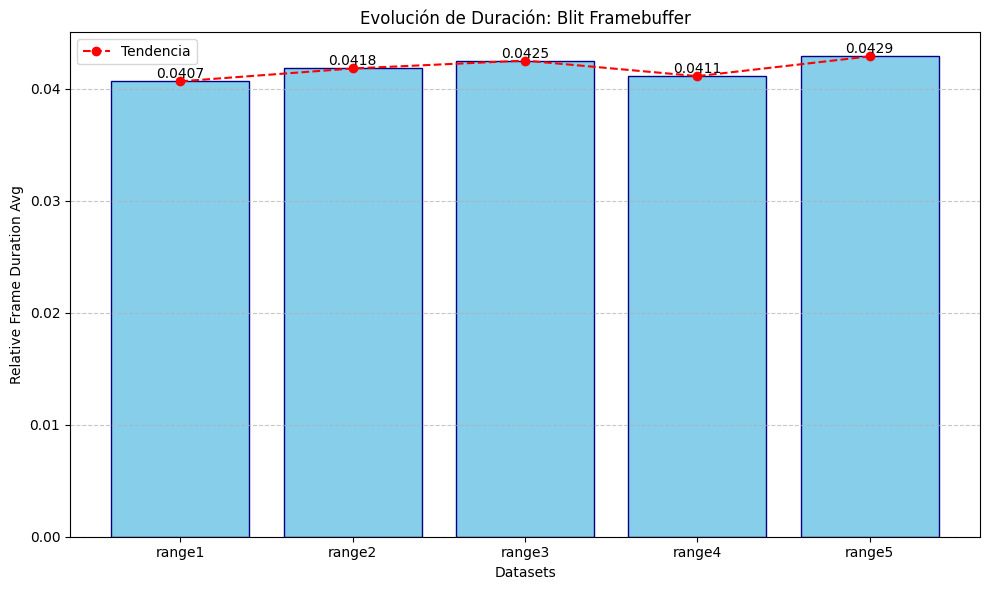

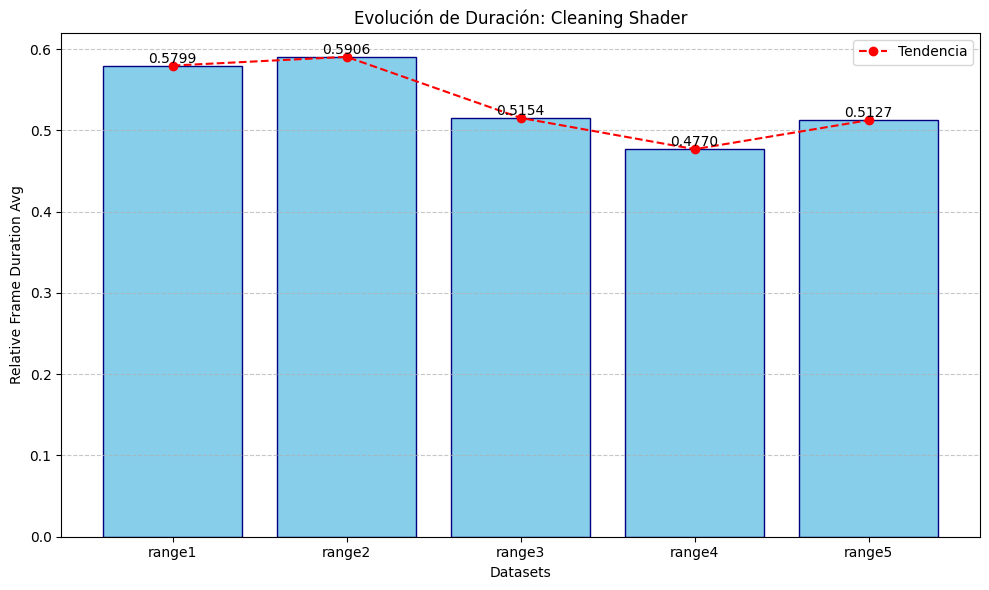

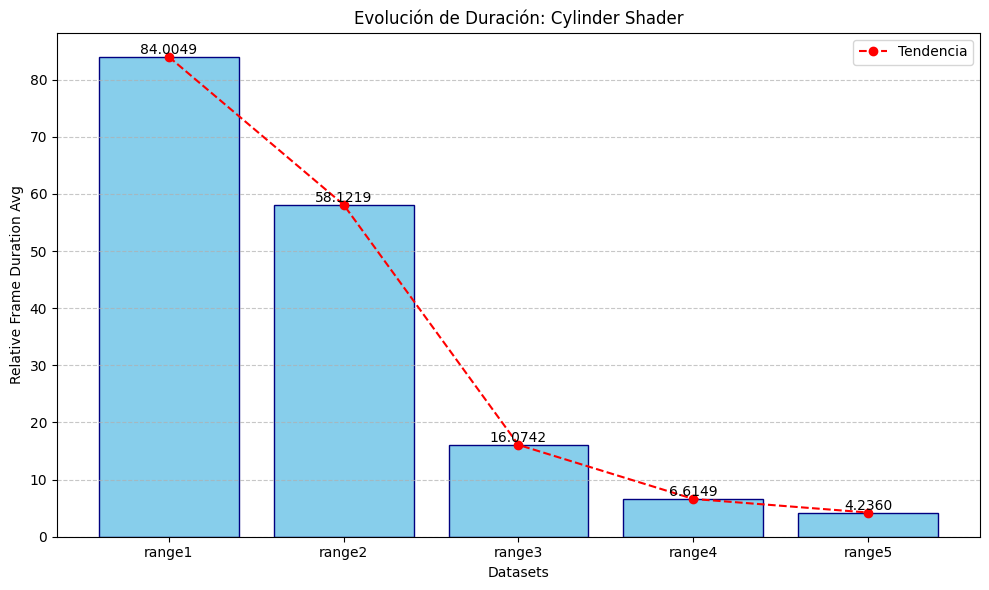

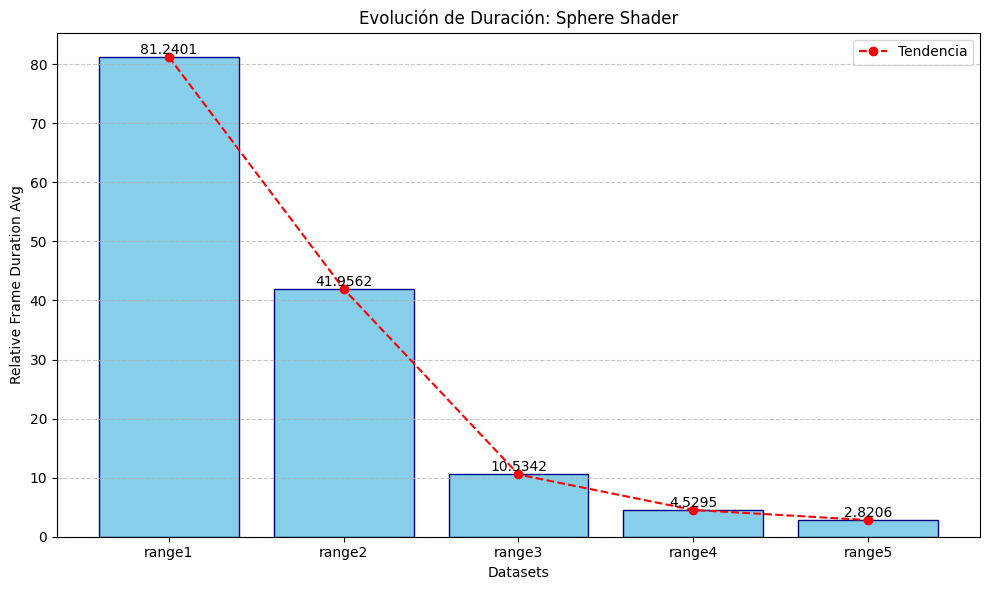

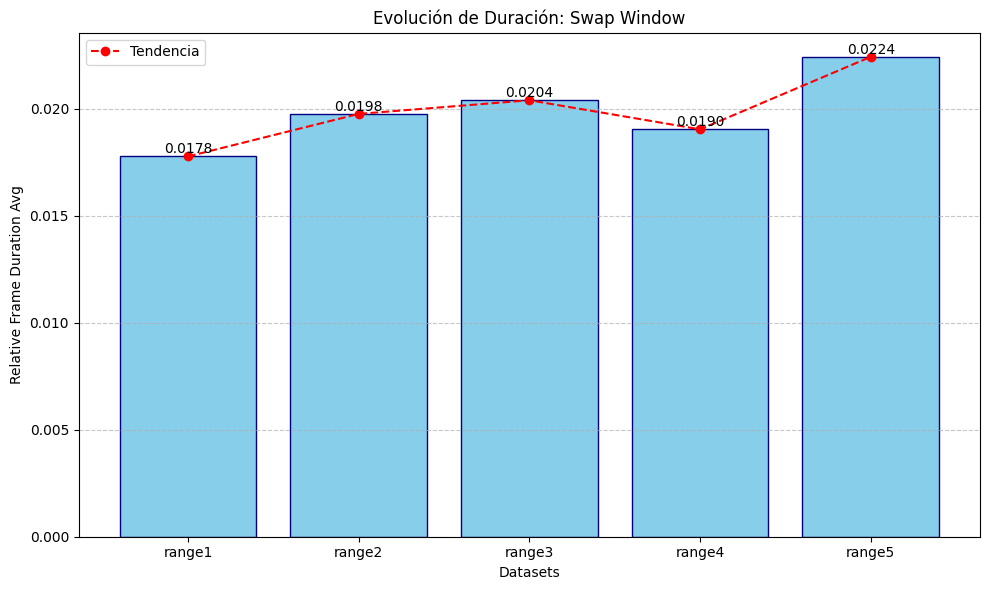

In [26]:
etiquetas_x = ["range1", "range2", "range3", "range4", "range5"]

# Asegúrate de ejecutar esto después de haber llenado 'cs_1st_1aga_ranges'
if 'cs_1st_1aga_ranges' in locals() and cs_1st_1aga_ranges:
    plotear_resultados_por_rango(cs_1st_1aga_ranges, etiquetas_x)
else:
    print("La variable 'cs_1st_1aga_ranges' no está definida o está vacía.")

Se encontraron 5 tipos de rangos para graficar: ['Blit Framebuffer', 'Cleaning Shader', 'Cylinder Shader', 'Sphere Shader', 'Swap Window']


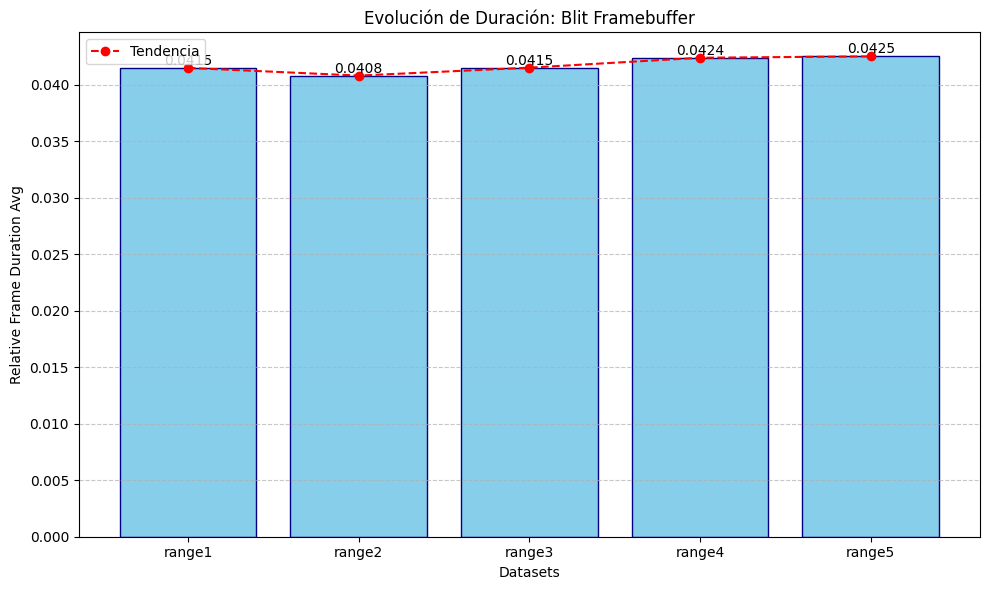

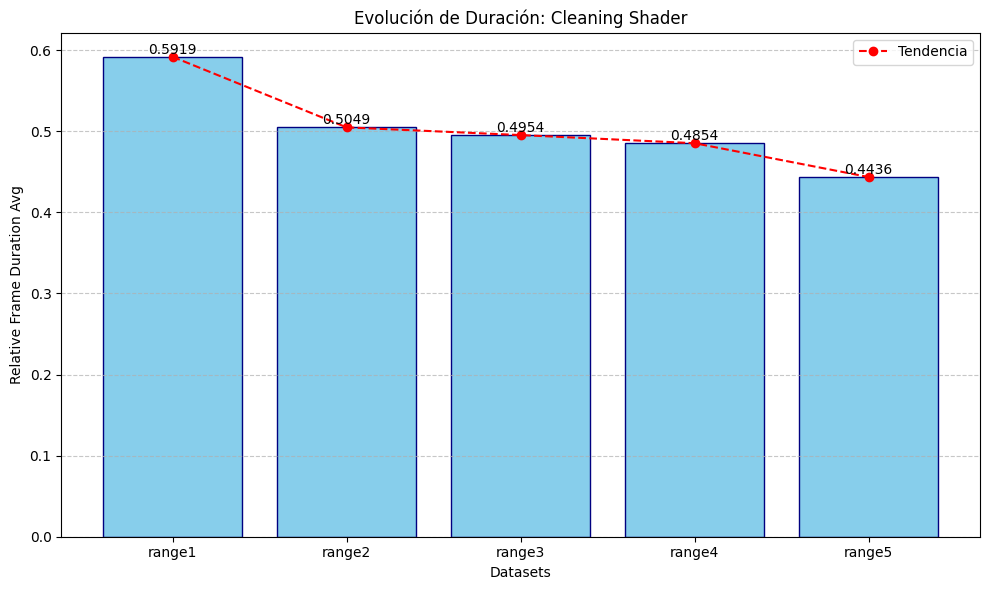

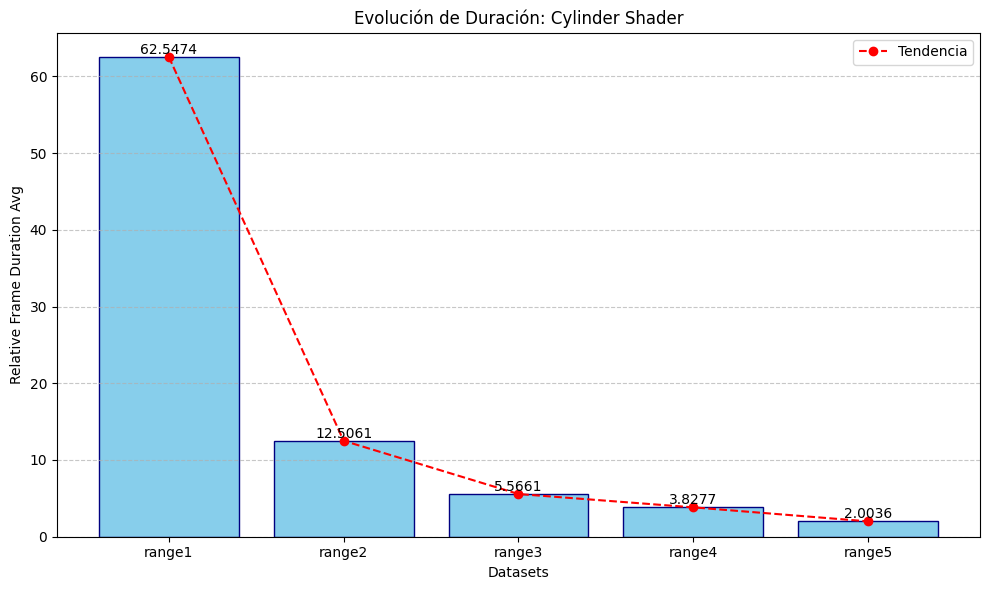

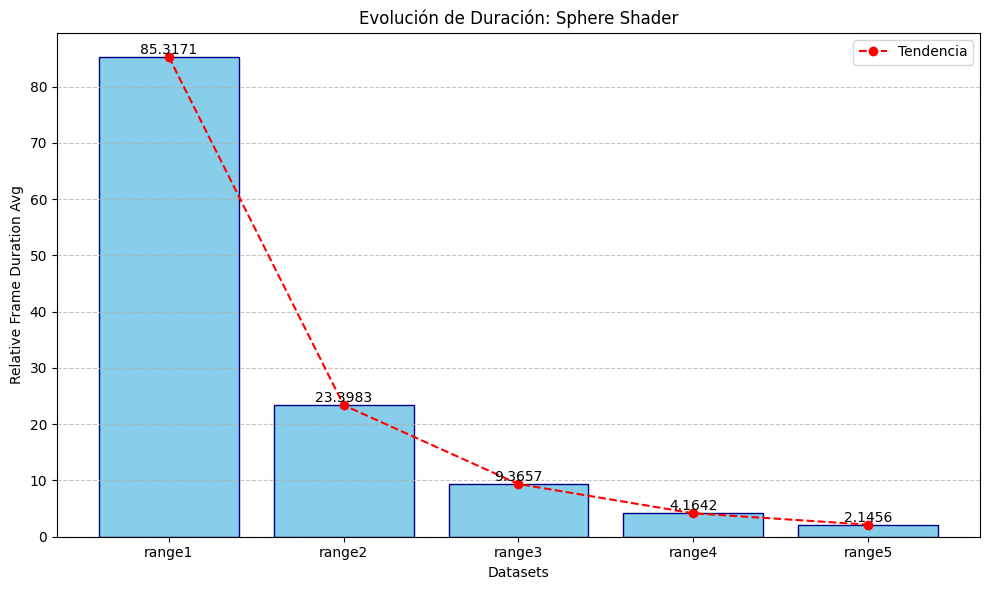

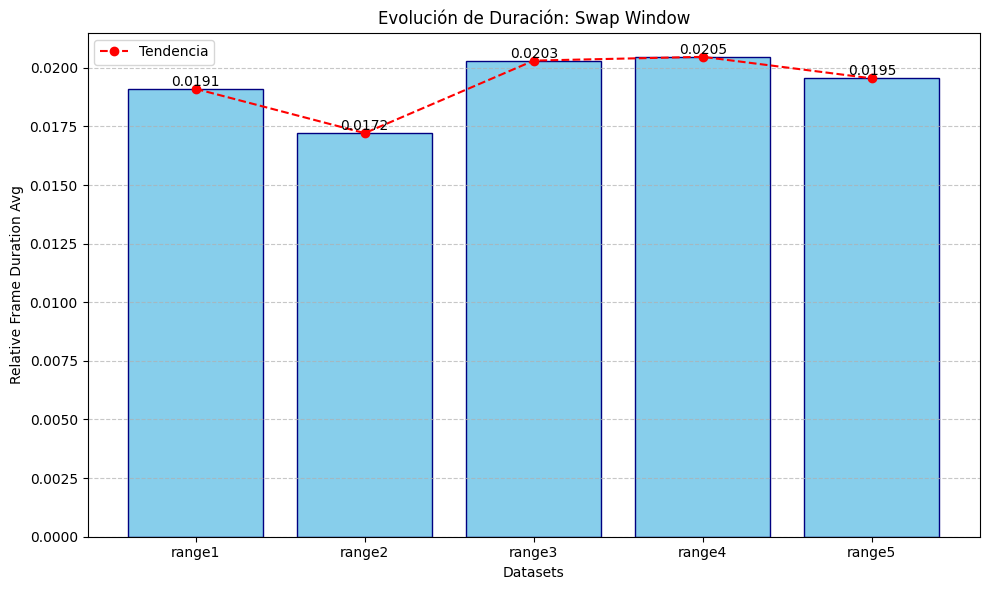

In [30]:
if 'cs_1st_1c0o_ranges' in locals() and cs_1st_1c0o_ranges:
    plotear_resultados_por_rango(cs_1st_1c0o_ranges, etiquetas_x)
else:
    print("La variable 'cs_1st_1c0o_ranges' no está definida o está vacía.")

Se encontraron 5 tipos de rangos para graficar: ['Blit Framebuffer', 'Cleaning Shader', 'Cylinder Shader', 'Sphere Shader', 'Swap Window']


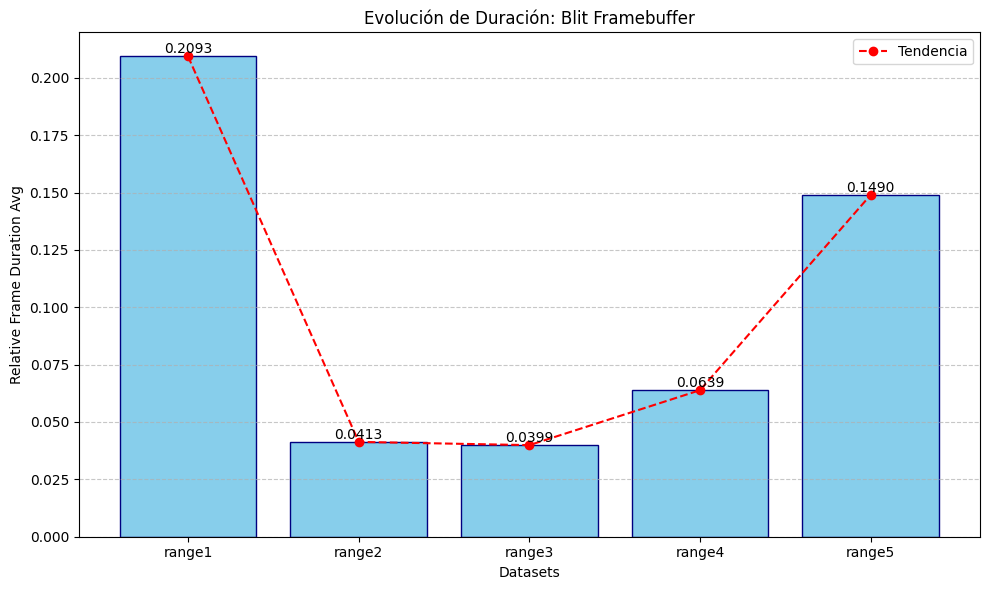

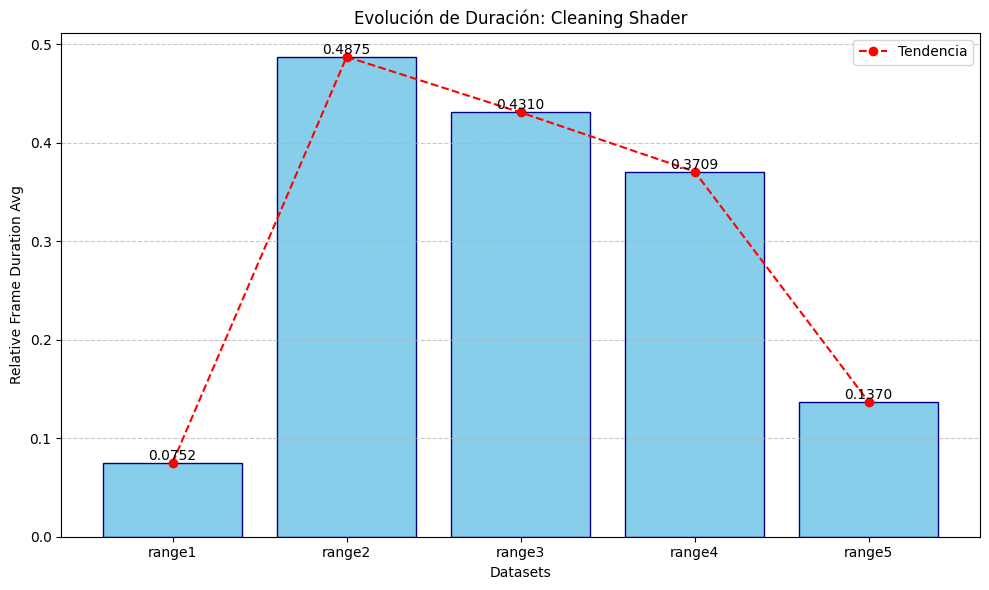

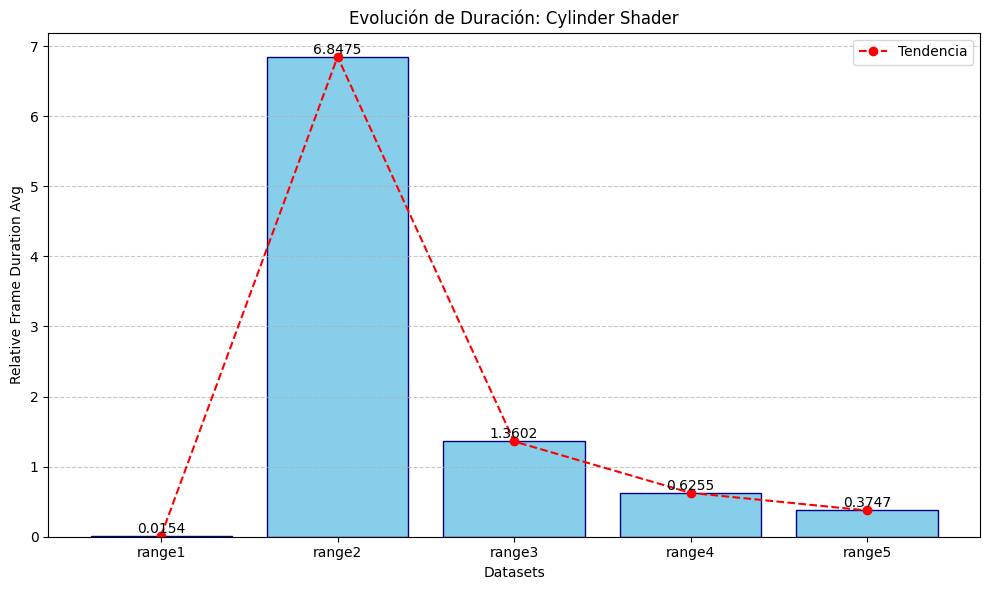

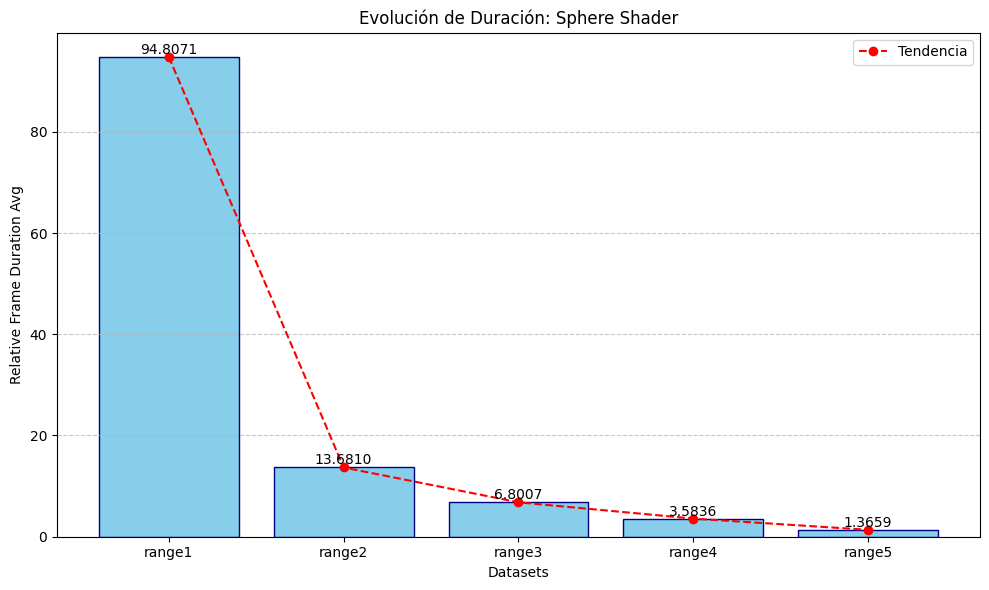

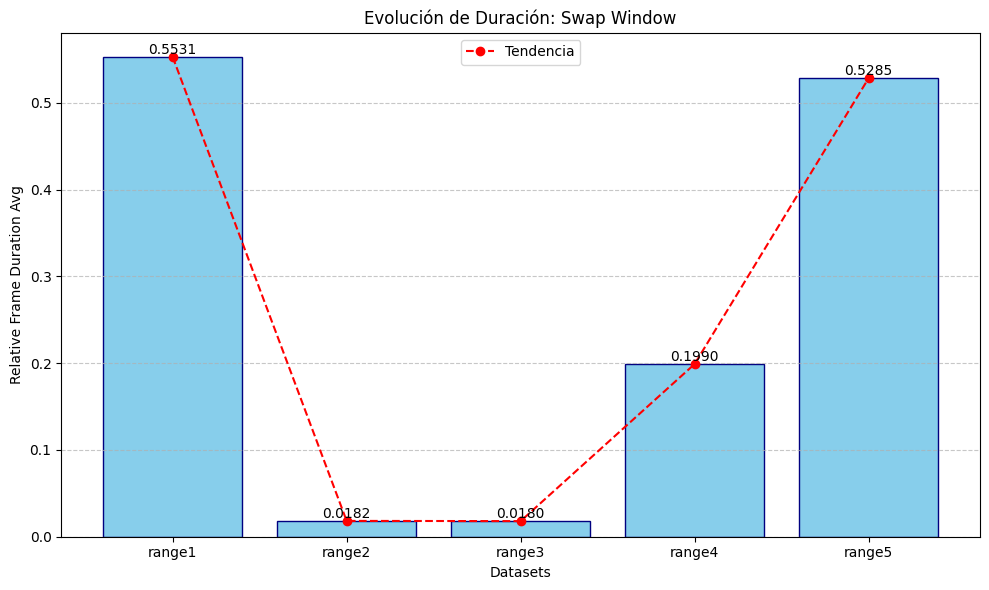

In [31]:
if 'cs_1st_2mjq_ranges' in locals() and cs_1st_2mjq_ranges:
    plotear_resultados_por_rango(cs_1st_2mjq_ranges, etiquetas_x)
else:
    print("La variable 'cs_1st_2mjq_ranges' no está definida o está vacía.")

Se encontraron 5 tipos de rangos para graficar: ['Blit Framebuffer', 'Cleaning Shader', 'Cylinder Shader', 'Sphere Shader', 'Swap Window']


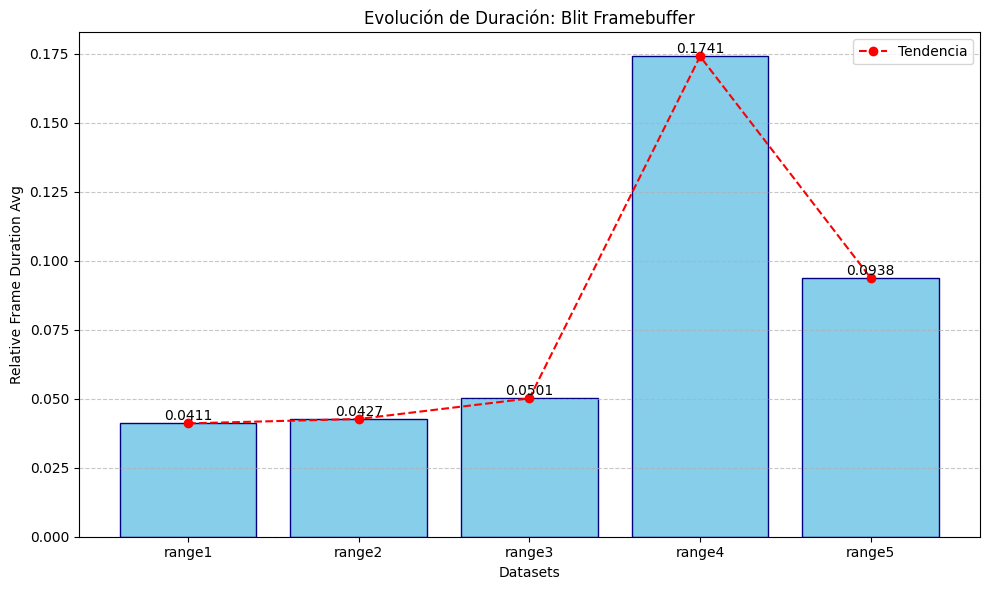

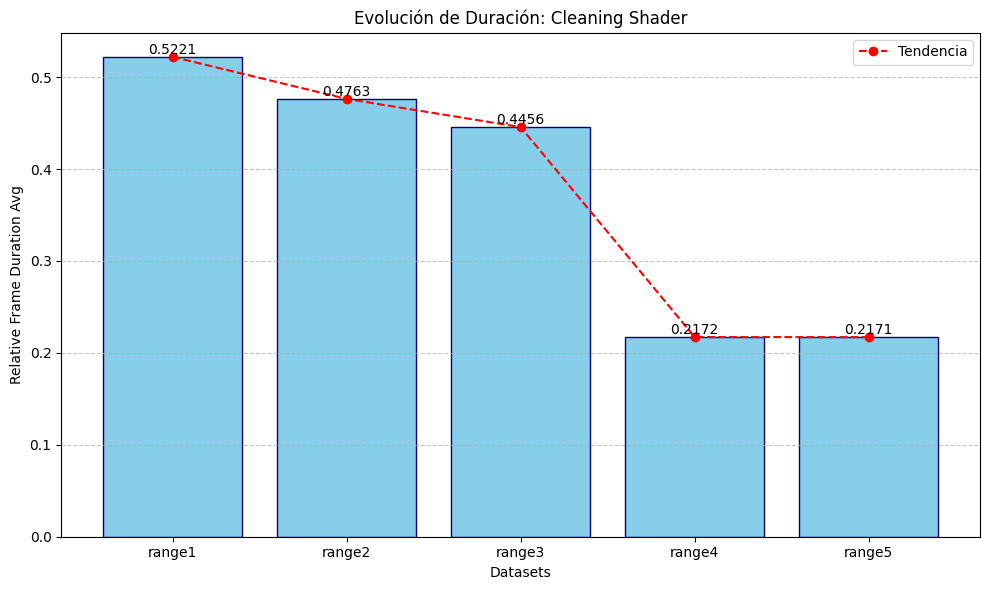

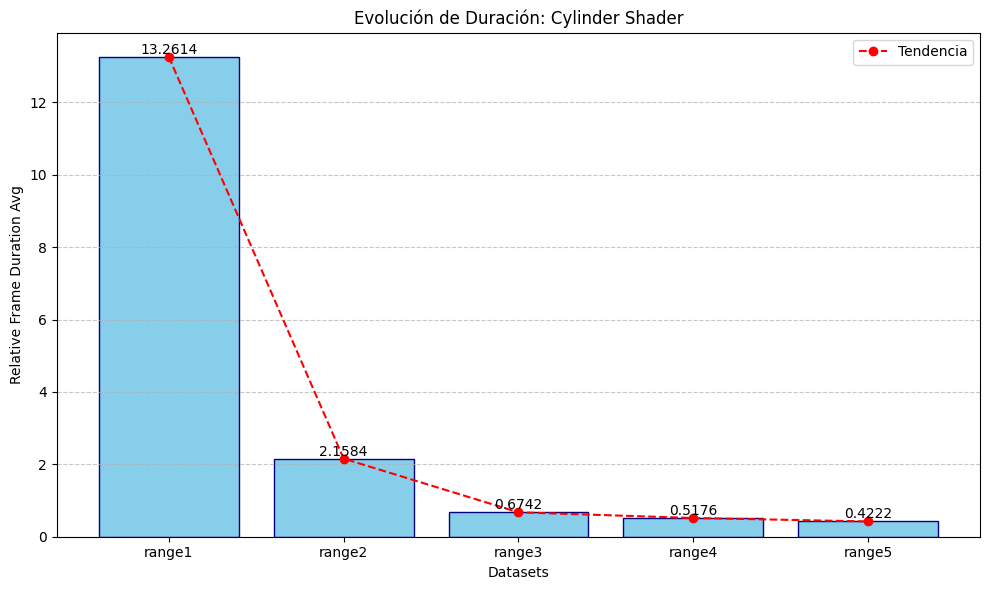

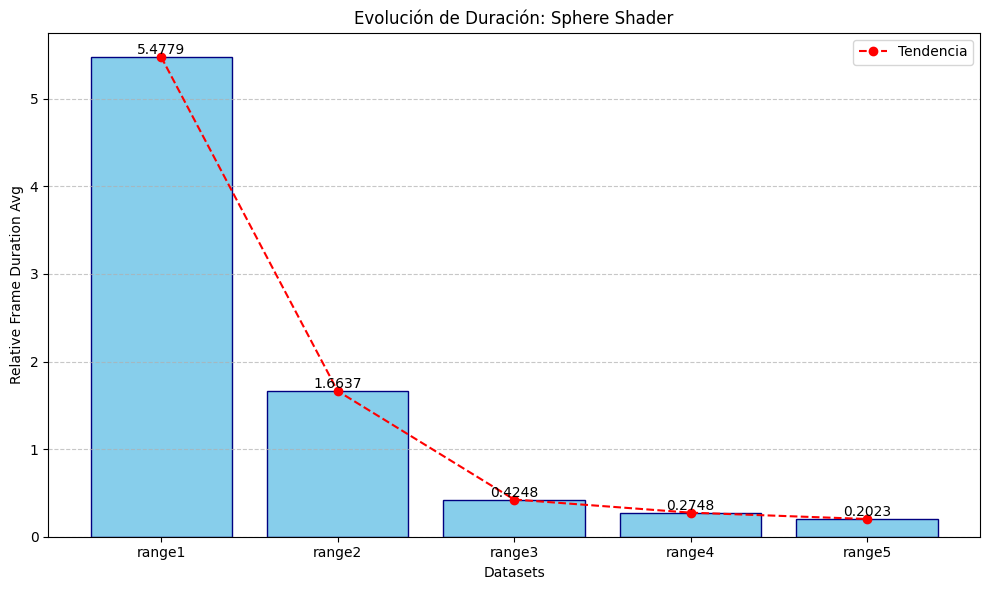

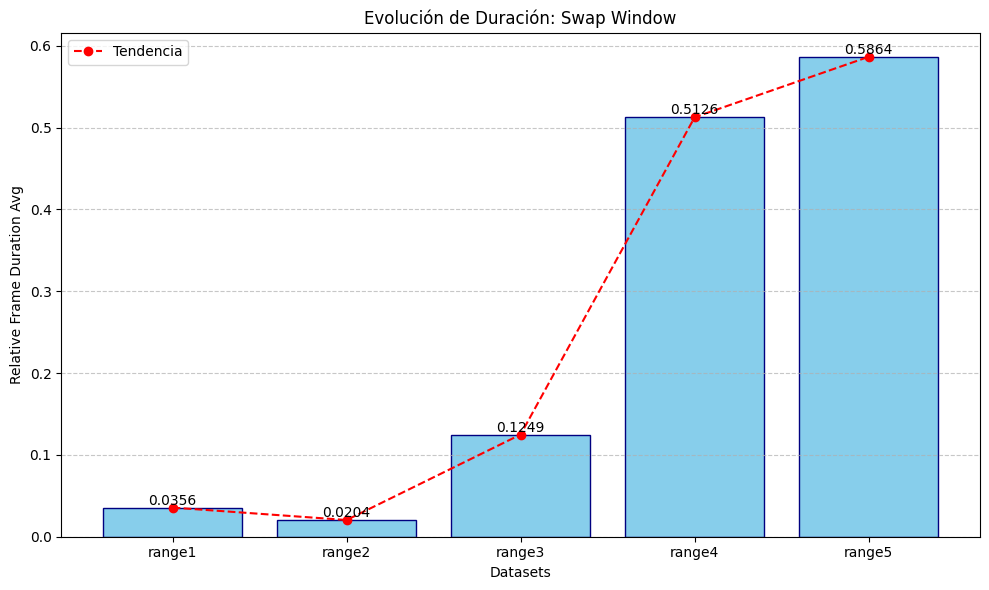

In [32]:
if 'cs_1st_8wql_ranges' in locals() and cs_1st_8wql_ranges:
    plotear_resultados_por_rango(cs_1st_8wql_ranges, etiquetas_x)
else:
    print("La variable 'cs_1st_8wql_ranges' no está definida o está vacía.")

In [48]:
cs_2nd_1aga_ranges = []
for i in range(5):
    cs_2nd_1aga_ranges.append(analizar_con_tiempos_reales(path_archivos["CS_2nd"]["1aga"][f"range{i+1}"], path_frames["CS_2nd"]["1aga"][f"range{i+1}"]))

Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_2nd/1aga/YAML/range1_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_2nd/1aga/YAML/range1_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_2nd/1aga/YAML/range1_3_analysis.yaml: Procesado correctamente.
Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_2nd/1aga/YAML/range2_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_2nd/1aga/YAML/range2_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_2nd/1aga/YAML/range2_3_analysis.yaml: Procesado correctamente.
Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_2nd/1aga/YAML/range3_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_2nd/1aga/YAML/range3_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_res

In [55]:
rearrange = {}
rearrange["range1"] = cs_2nd_1aga_ranges[0]
rearrange["range2"] = cs_2nd_1aga_ranges[1]
rearrange["range3"] = cs_2nd_1aga_ranges[2]
rearrange["range4"] = cs_2nd_1aga_ranges[3]
rearrange["range5"] = cs_2nd_1aga_ranges[4]
guardar_resultados_json(rearrange, nombre_archivo="resultados_cs_2nd_1aga_ranges.json")

✅ Datos guardados exitosamente en: resultados_cs_2nd_1aga_ranges.json


In [49]:
cs_2nd_1c0o_ranges = []
for i in range(5):
    cs_2nd_1c0o_ranges.append(analizar_con_tiempos_reales(path_archivos["CS_2nd"]["1c0o"][f"range{i+1}"], path_frames["CS_2nd"]["1c0o"][f"range{i+1}"]))

Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_2nd/1c0o/YAML/range1_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_2nd/1c0o/YAML/range1_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_2nd/1c0o/YAML/range1_3_analysis.yaml: Procesado correctamente.
Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_2nd/1c0o/YAML/range2_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_2nd/1c0o/YAML/range2_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_2nd/1c0o/YAML/range2_3_analysis.yaml: Procesado correctamente.
Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_2nd/1c0o/YAML/range3_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_2nd/1c0o/YAML/range3_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_res

In [54]:
rearrange = {}
rearrange["range1"] = cs_2nd_1c0o_ranges[0]
rearrange["range2"] = cs_2nd_1c0o_ranges[1]
rearrange["range3"] = cs_2nd_1c0o_ranges[2]
rearrange["range4"] = cs_2nd_1c0o_ranges[3]
rearrange["range5"] = cs_2nd_1c0o_ranges[4]
guardar_resultados_json(rearrange, nombre_archivo="resultados_cs_2nd_1c0o_ranges.json")

✅ Datos guardados exitosamente en: resultados_cs_2nd_1c0o_ranges.json


In [53]:
cs_2nd_2mjq_ranges = []
for i in range(5):
    cs_2nd_2mjq_ranges.append(analizar_con_tiempos_reales(path_archivos["CS_2nd"]["2mjq"][f"range{i+1}"], path_frames["CS_2nd"]["2mjq"][f"range{i+1}"]))

Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_2nd/2mjq/YAML/range1_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_2nd/2mjq/YAML/range1_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_2nd/2mjq/YAML/range1_3_analysis.yaml: Procesado correctamente.
Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_2nd/2mjq/YAML/range2_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_2nd/2mjq/YAML/range2_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_2nd/2mjq/YAML/range2_3_analysis.yaml: Procesado correctamente.
Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_2nd/2mjq/YAML/range3_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_2nd/2mjq/YAML/range3_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_res

In [52]:
rearrange = {}
rearrange["range1"] = cs_2nd_2mjq_ranges[0]
rearrange["range2"] = cs_2nd_2mjq_ranges[1]
rearrange["range3"] = cs_2nd_2mjq_ranges[2]
rearrange["range4"] = cs_2nd_2mjq_ranges[3]
rearrange["range5"] = cs_2nd_2mjq_ranges[4]
guardar_resultados_json(rearrange, nombre_archivo="resultados_cs_2nd_2mjq_ranges.json")

✅ Datos guardados exitosamente en: resultados_cs_2nd_2mjq_ranges.json


Se encontraron 7 tipos de rangos para graficar: ['Blit Framebuffer', 'Cleaning Shader', 'Cylinder Bbox Extraction Shader', 'Cylinder Bbox Intersection Shader', 'Sphere Bbox Extraction Shader', 'Sphere Bbox Intersection Shader', 'Swap Window']


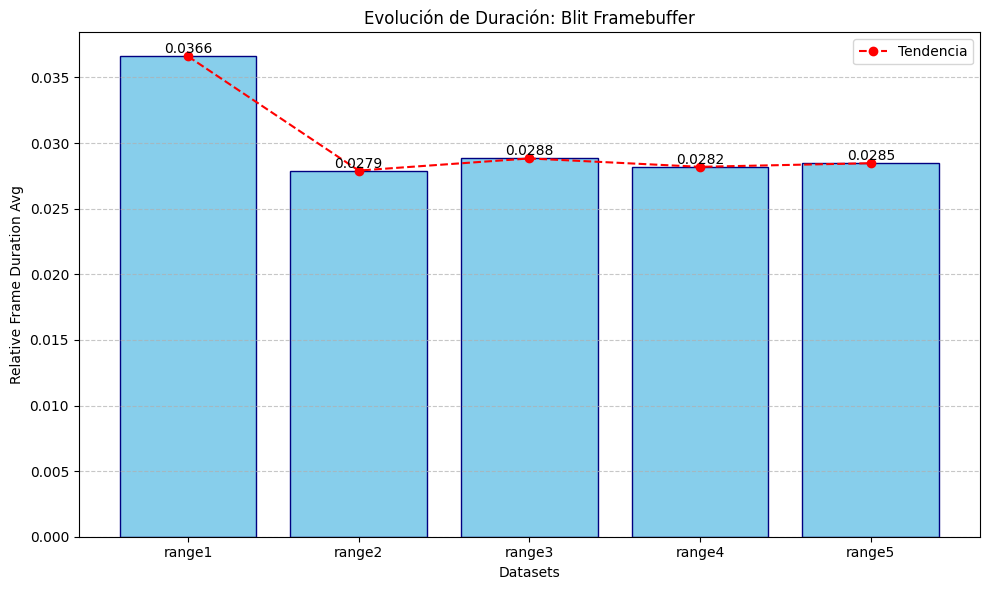

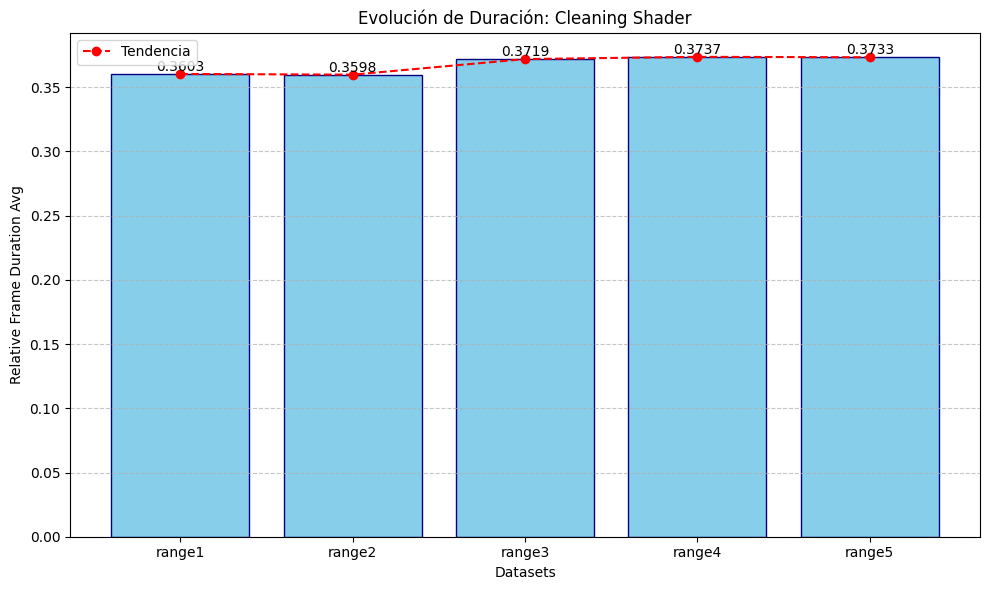

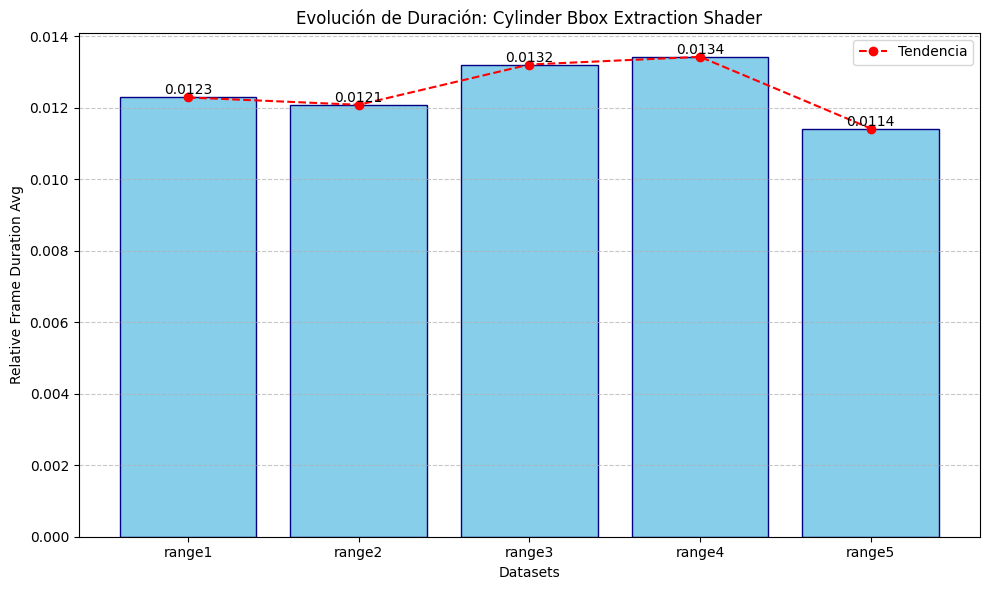

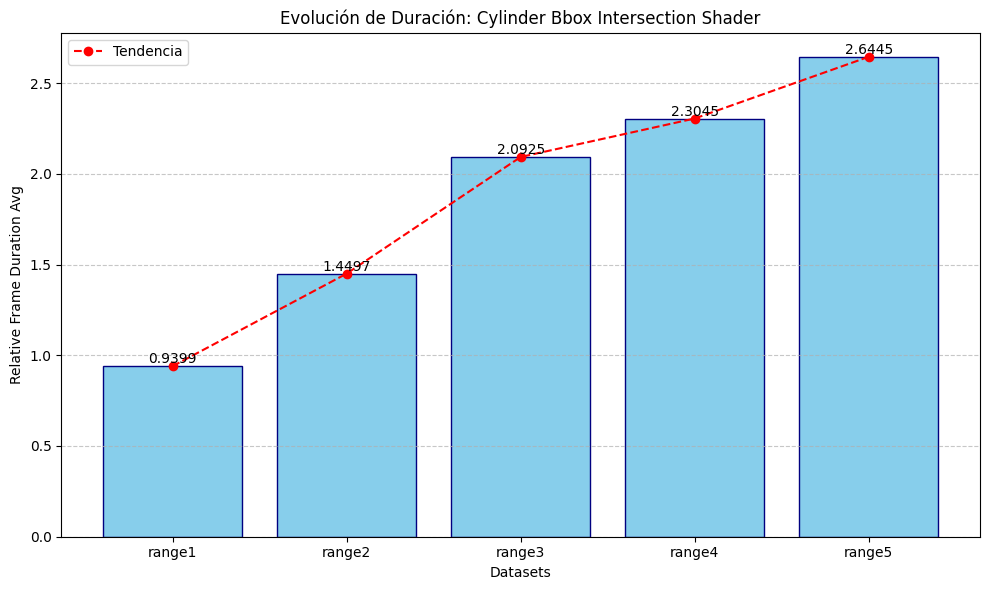

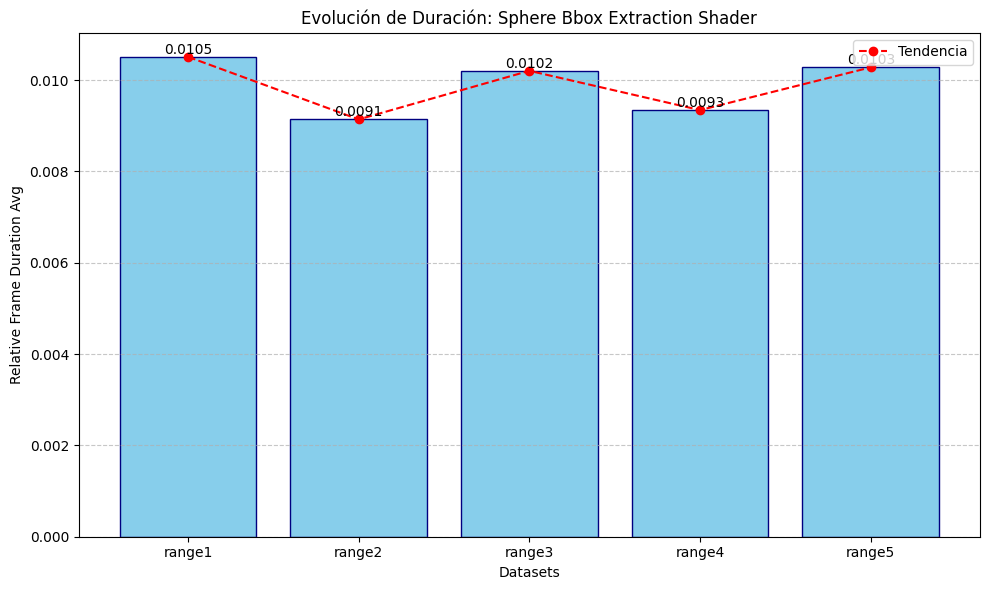

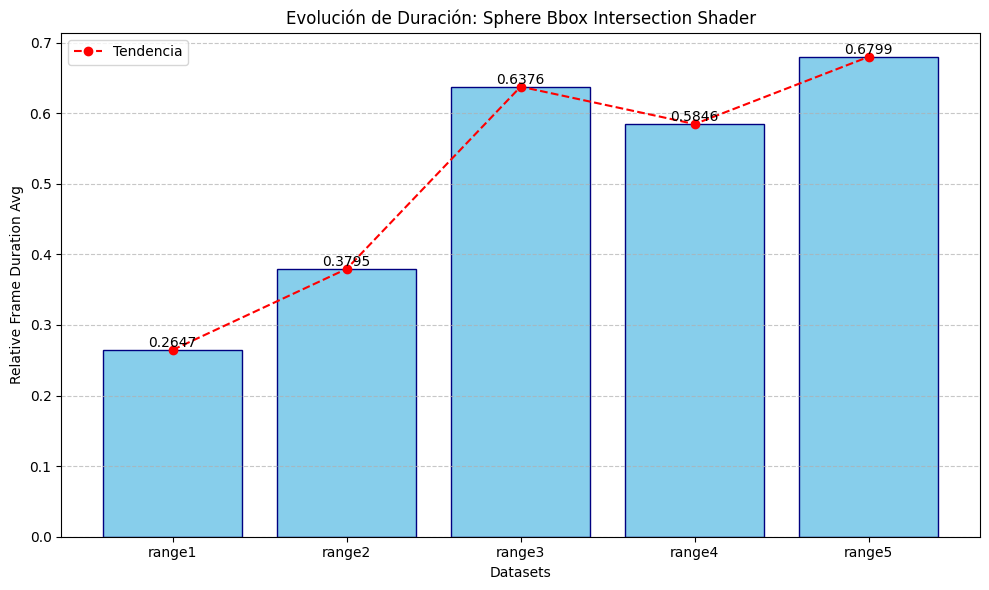

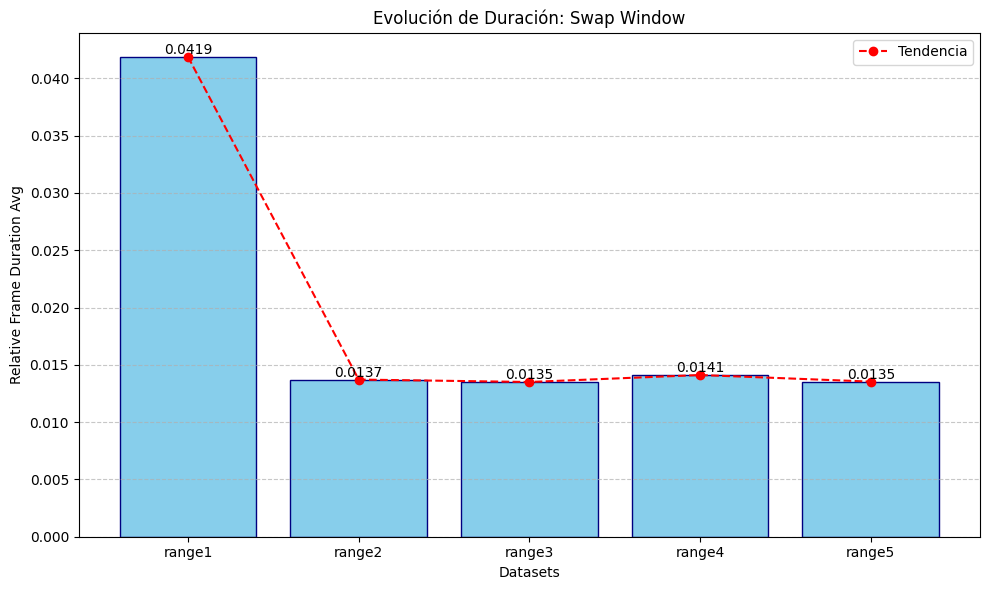

In [ ]:
if 'cs_2nd_1aga_ranges' in locals() and cs_2nd_1aga_ranges:
    plotear_resultados_por_rango(cs_2nd_1aga_ranges, etiquetas_x)
else:
    print("La variable 'cs_2nd_1aga_ranges' no está definida o está vacía.")

Se encontraron 7 tipos de rangos para graficar: ['Blit Framebuffer', 'Cleaning Shader', 'Cylinder Bbox Extraction Shader', 'Cylinder Bbox Intersection Shader', 'Sphere Bbox Extraction Shader', 'Sphere Bbox Intersection Shader', 'Swap Window']


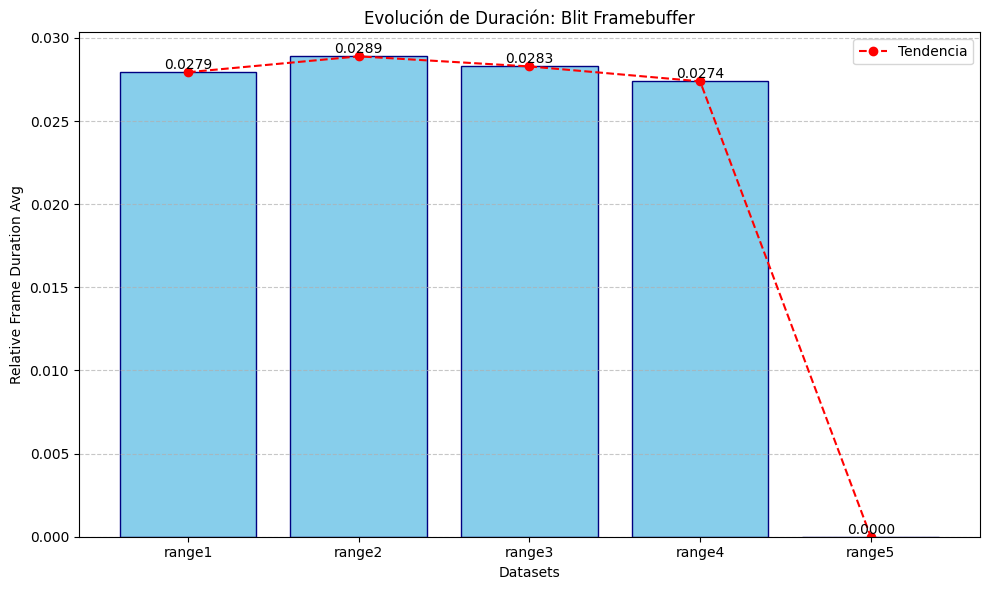

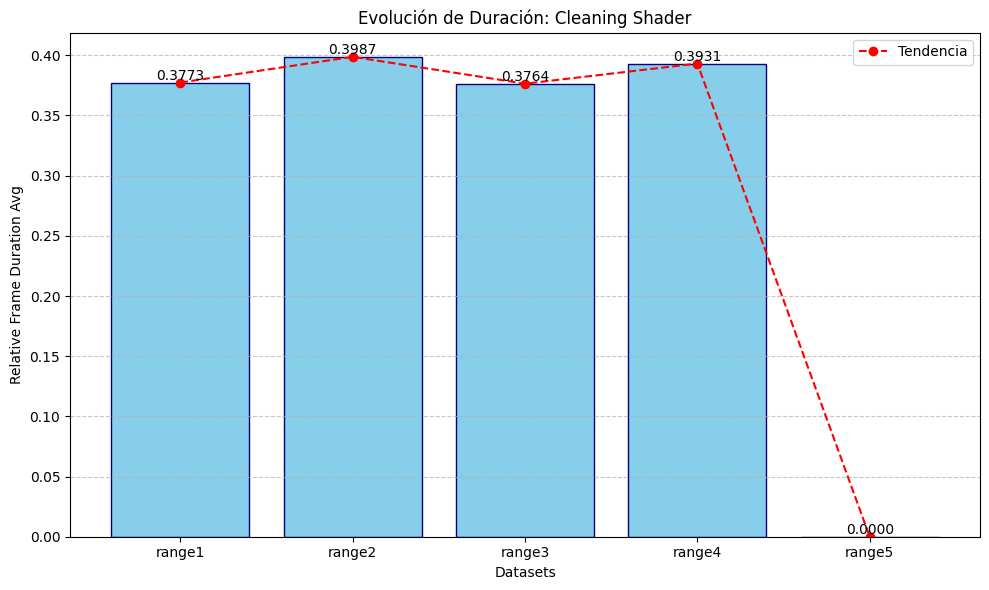

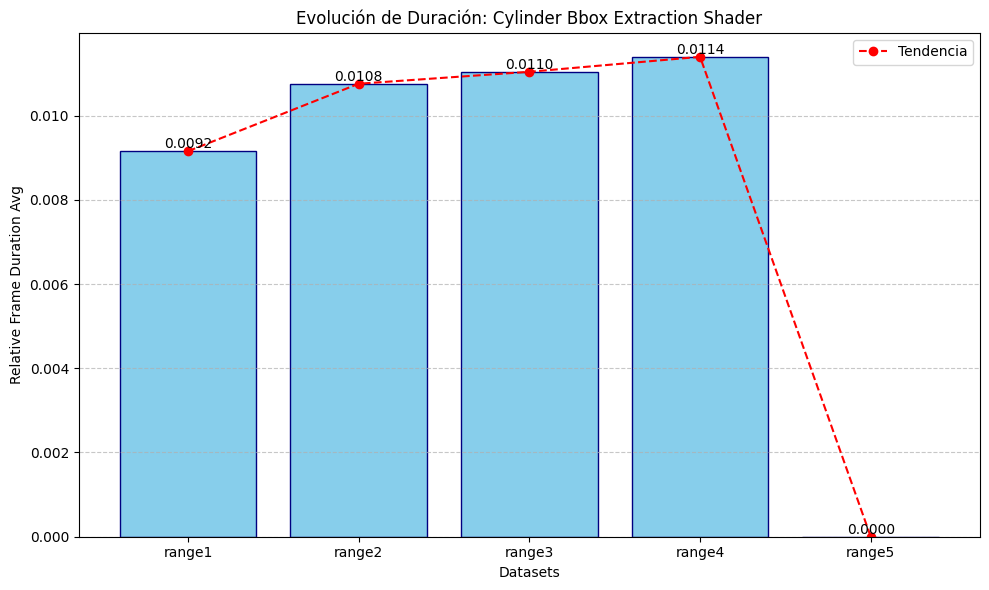

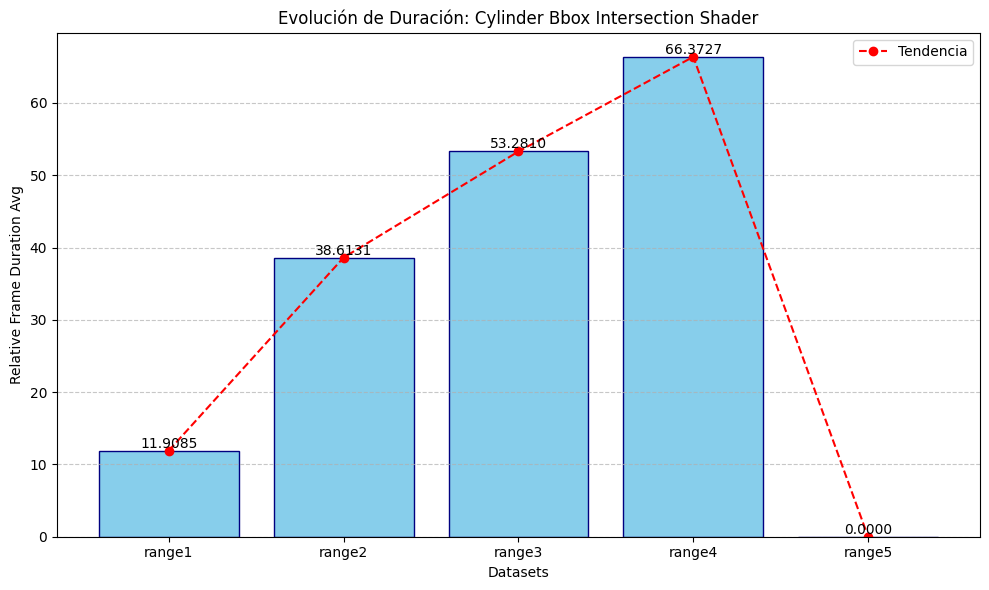

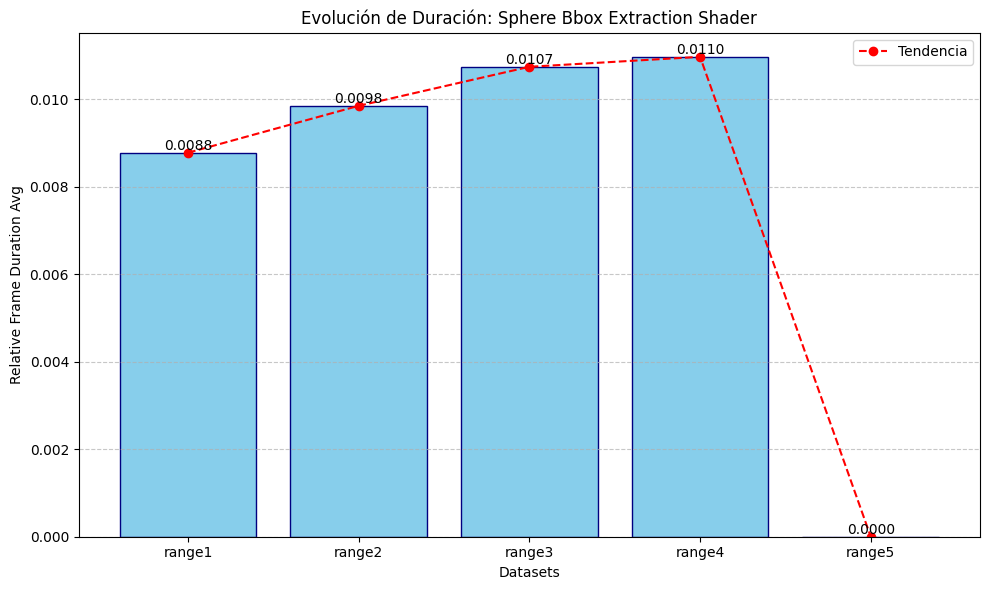

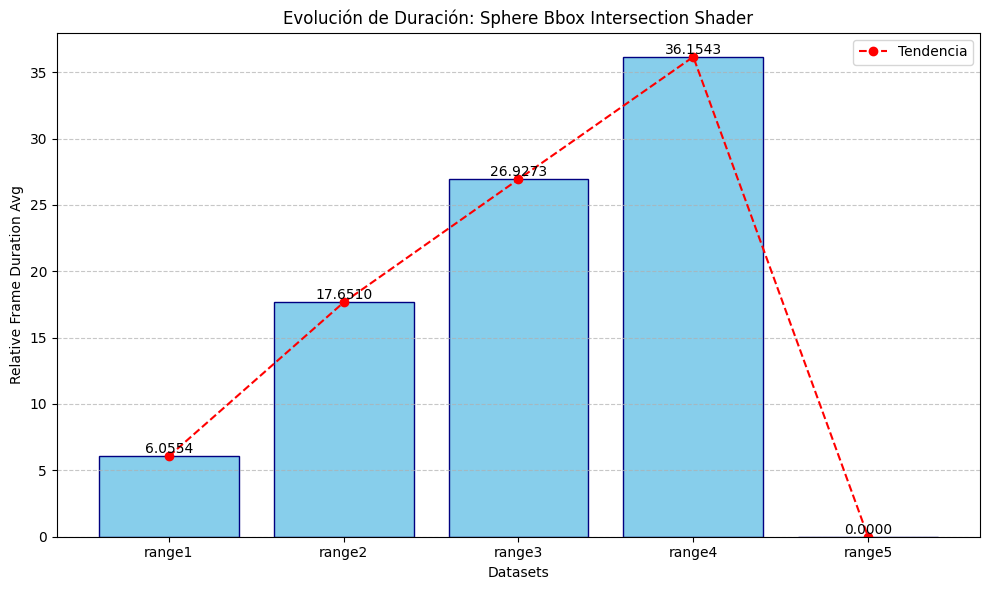

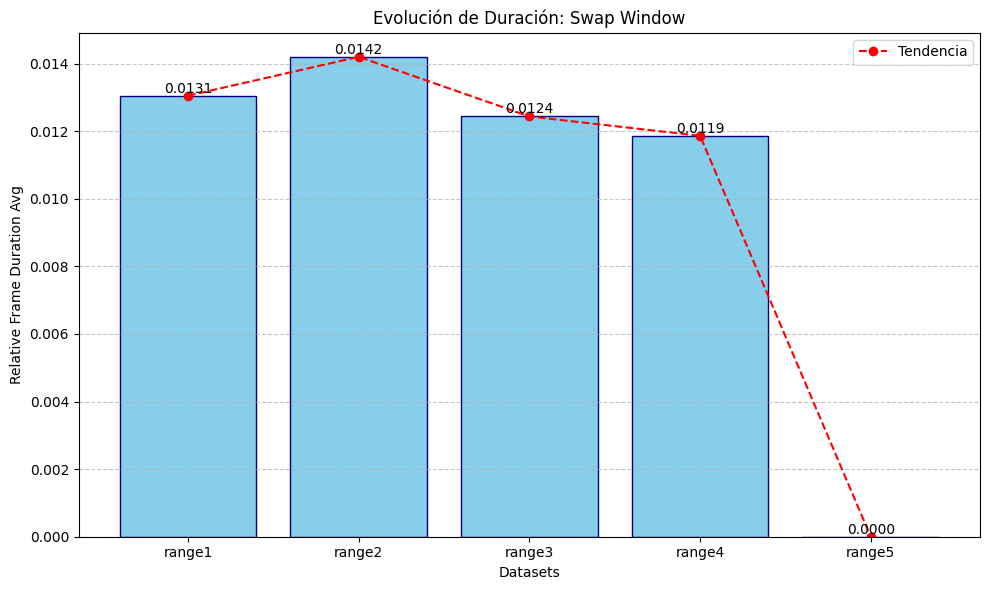

In [57]:
if 'cs_2nd_1c0o_ranges' in locals() and cs_2nd_1c0o_ranges:
    plotear_resultados_por_rango(cs_2nd_1c0o_ranges, etiquetas_x)
else:
    print("La variable 'cs_2nd_1c0o_ranges' no está definida o está vacía.")

Se encontraron 7 tipos de rangos para graficar: ['Blit Framebuffer', 'Cleaning Shader', 'Cylinder Bbox Extraction Shader', 'Cylinder Bbox Intersection Shader', 'Sphere Bbox Extraction Shader', 'Sphere Bbox Intersection Shader', 'Swap Window']


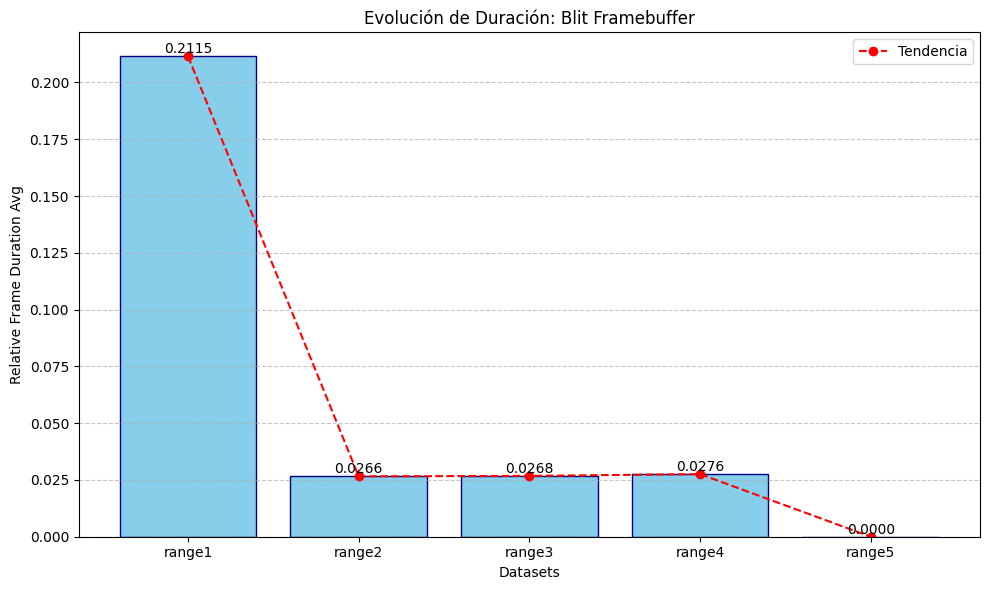

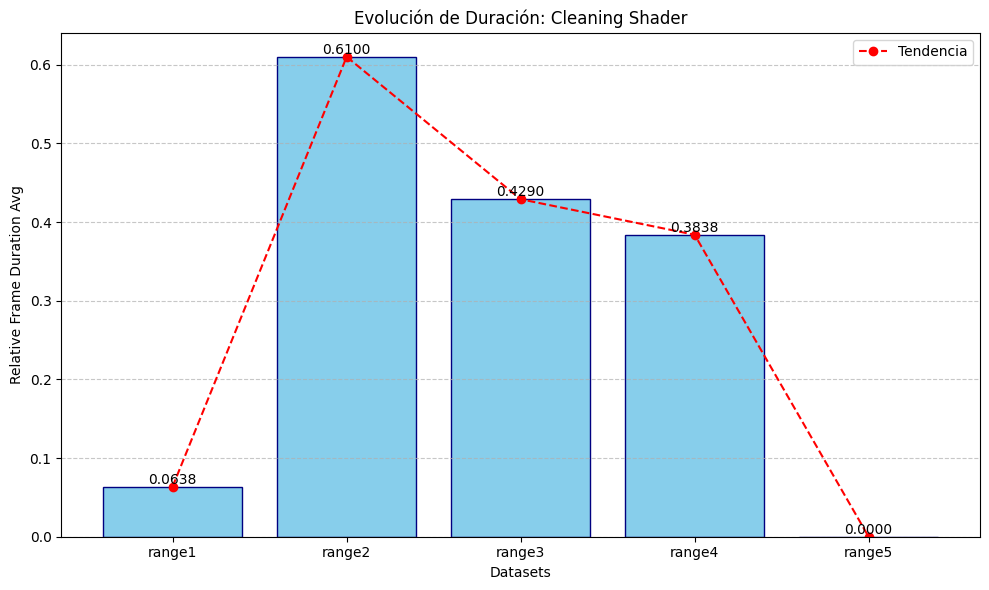

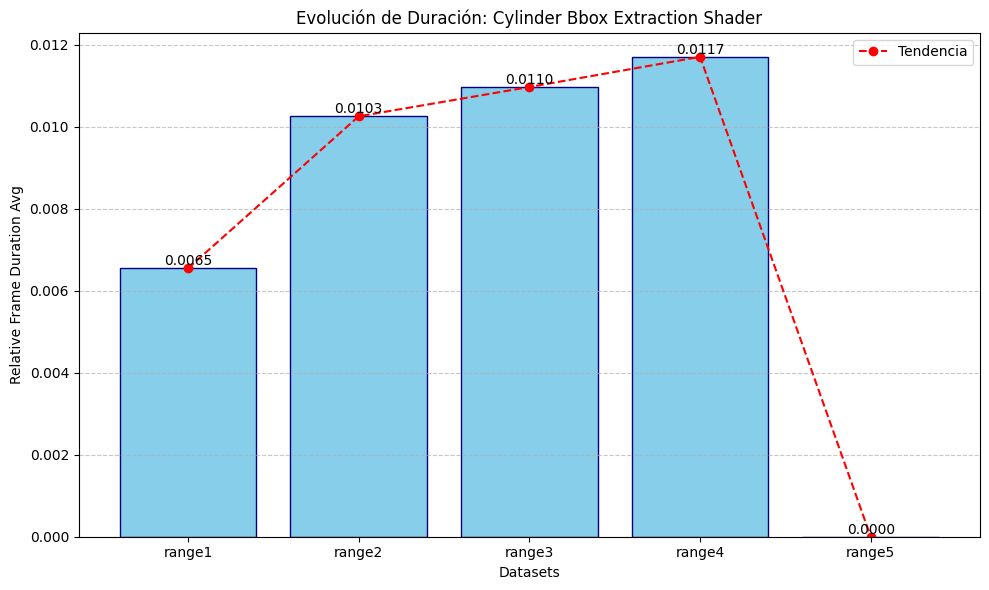

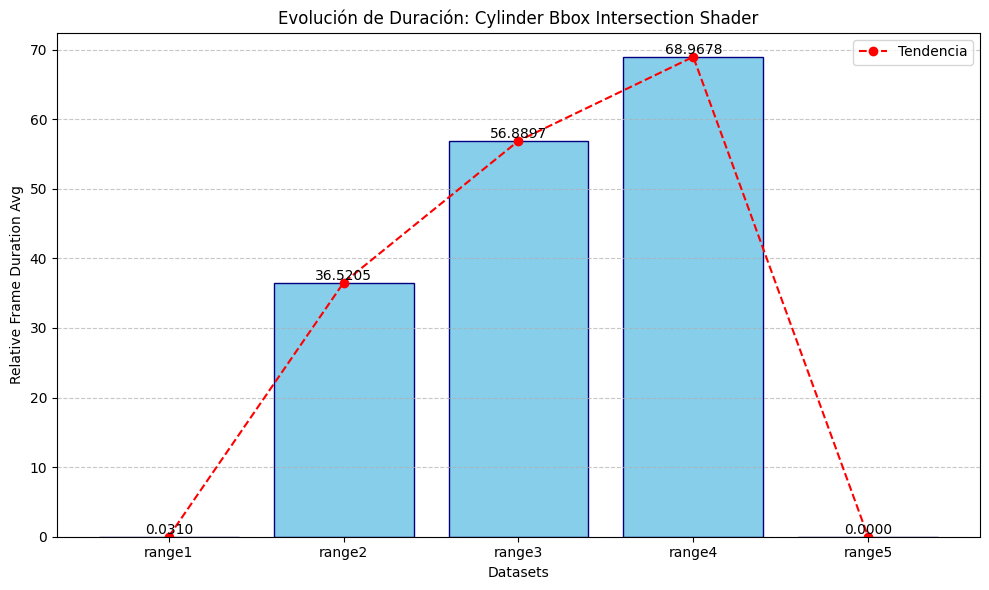

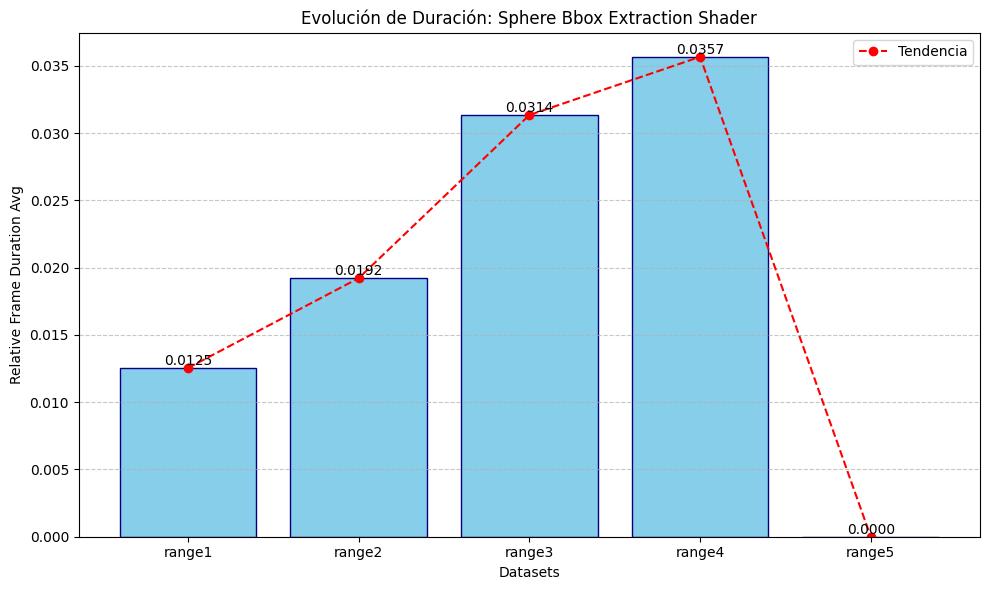

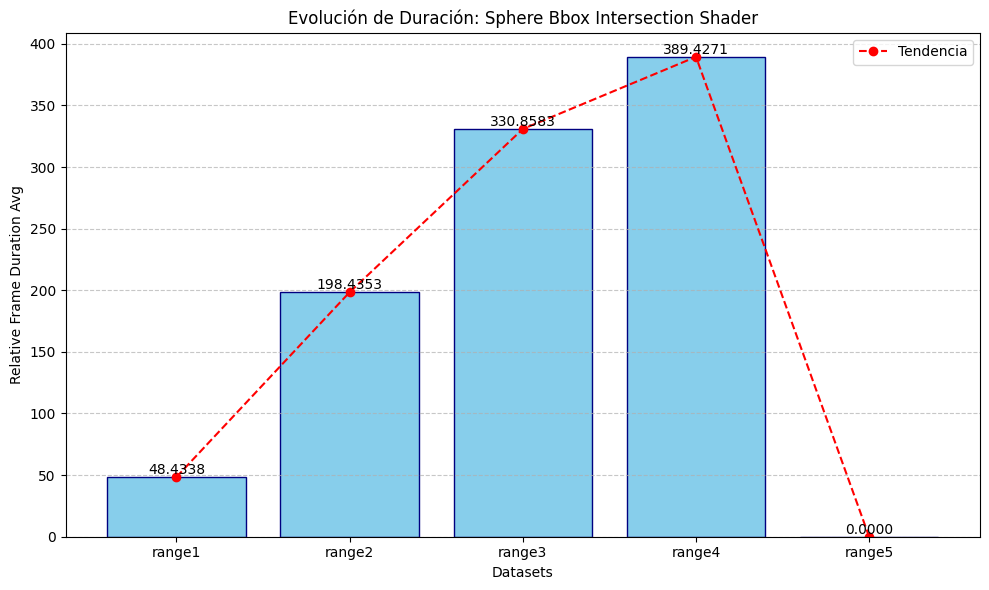

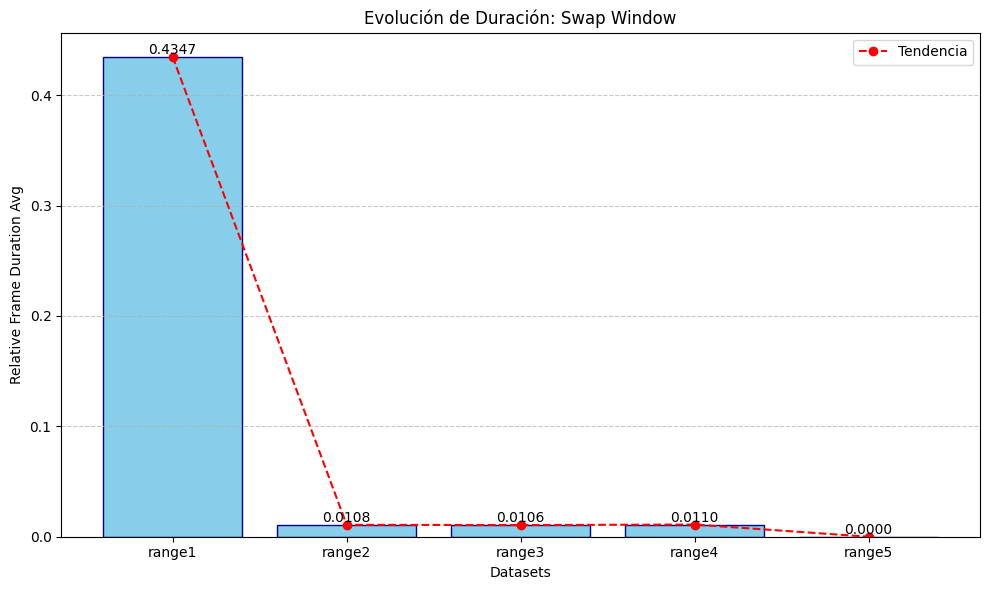

In [58]:
if 'cs_2nd_2mjq_ranges' in locals() and cs_2nd_2mjq_ranges:
    plotear_resultados_por_rango(cs_2nd_2mjq_ranges, etiquetas_x)
else:
    print("La variable 'cs_2nd_2mjq_ranges' no está definida o está vacía.")

In [59]:
cs_std_1aga_ranges = []
for i in range(5):
    cs_std_1aga_ranges.append(analizar_con_tiempos_reales(path_archivos["CS_std"]["1aga"][f"range{i+1}"], path_frames["CS_std"]["1aga"][f"range{i+1}"]))

rearrange = {}
rearrange["range1"] = cs_std_1aga_ranges[0]
rearrange["range2"] = cs_std_1aga_ranges[1]
rearrange["range3"] = cs_std_1aga_ranges[2]
rearrange["range4"] = cs_std_1aga_ranges[3]
rearrange["range5"] = cs_std_1aga_ranges[4]
guardar_resultados_json(rearrange, nombre_archivo="resultados_cs_std_1aga_ranges.json")

Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_std/1aga/YAML/range1_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_std/1aga/YAML/range1_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_std/1aga/YAML/range1_3_analysis.yaml: Procesado correctamente.
Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_std/1aga/YAML/range2_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_std/1aga/YAML/range2_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_std/1aga/YAML/range2_3_analysis.yaml: Procesado correctamente.
Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_std/1aga/YAML/range3_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_std/1aga/YAML/range3_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_res

In [60]:
cs_std_1c0o_ranges = []
for i in range(5):
    cs_std_1c0o_ranges.append(analizar_con_tiempos_reales(path_archivos["CS_std"]["1c0o"][f"range{i+1}"], path_frames["CS_std"]["1c0o"][f"range{i+1}"]))

rearrange = {}
rearrange["range1"] = cs_std_1c0o_ranges[0]
rearrange["range2"] = cs_std_1c0o_ranges[1]
rearrange["range3"] = cs_std_1c0o_ranges[2]
rearrange["range4"] = cs_std_1c0o_ranges[3]
rearrange["range5"] = cs_std_1c0o_ranges[4]
guardar_resultados_json(rearrange, nombre_archivo="resultados_cs_std_1c0o_ranges.json")

Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_std/1c0o/YAML/range1_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_std/1c0o/YAML/range1_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_std/1c0o/YAML/range1_3_analysis.yaml: Procesado correctamente.
Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_std/1c0o/YAML/range2_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_std/1c0o/YAML/range2_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_std/1c0o/YAML/range2_3_analysis.yaml: Procesado correctamente.
Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_std/1c0o/YAML/range3_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_std/1c0o/YAML/range3_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_res

In [62]:
cs_std_2mjq_ranges = []
for i in range(5):
    cs_std_2mjq_ranges.append(analizar_con_tiempos_reales(path_archivos["CS_std"]["2mjq"][f"range{i+1}"], path_frames["CS_std"]["2mjq"][f"range{i+1}"]))

rearrange = {}
rearrange["range1"] = cs_std_2mjq_ranges[0]
rearrange["range2"] = cs_std_2mjq_ranges[1]
rearrange["range3"] = cs_std_2mjq_ranges[2]
rearrange["range4"] = cs_std_2mjq_ranges[3]
rearrange["range5"] = cs_std_2mjq_ranges[4]
guardar_resultados_json(rearrange, nombre_archivo="resultados_cs_std_2mjq_ranges.json")

Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_std/2mjq/YAML/range1_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_std/2mjq/YAML/range1_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_std/2mjq/YAML/range1_3_analysis.yaml: Procesado correctamente.
Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_std/2mjq/YAML/range2_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_std/2mjq/YAML/range2_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_std/2mjq/YAML/range2_3_analysis.yaml: Procesado correctamente.
Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_std/2mjq/YAML/range3_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_std/2mjq/YAML/range3_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_res

In [61]:
cs_std_8wql_ranges = []
for i in range(5):
    cs_std_8wql_ranges.append(analizar_con_tiempos_reales(path_archivos["CS_std"]["8wql"][f"range{i+1}"], path_frames["CS_std"]["8wql"][f"range{i+1}"]))

rearrange = {}
rearrange["range1"] = cs_std_8wql_ranges[0]
rearrange["range2"] = cs_std_8wql_ranges[1]
rearrange["range3"] = cs_std_8wql_ranges[2]
rearrange["range4"] = cs_std_8wql_ranges[3]
rearrange["range5"] = cs_std_8wql_ranges[4]
guardar_resultados_json(rearrange, nombre_archivo="resultados_cs_std_8wql_ranges.json")

Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_std/8wql/YAML/range1_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_std/8wql/YAML/range1_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_std/8wql/YAML/range1_3_analysis.yaml: Procesado correctamente.
Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_std/8wql/YAML/range2_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_std/8wql/YAML/range2_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_std/8wql/YAML/range2_3_analysis.yaml: Procesado correctamente.
Se cargaron 3 bloques de tiempos de frames.

Procesando y sincronizando archivos...
 -> ../nsight_gr_results/CS_std/8wql/YAML/range3_1_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_results/CS_std/8wql/YAML/range3_2_analysis.yaml: Procesado correctamente.
 -> ../nsight_gr_res

Se encontraron 6 tipos de rangos para graficar: ['Blit Framebuffer', 'Cylinder Culling Shader', 'Draw Cylinders', 'Draw Spheres', 'Sphere Culling Shader', 'Swap Window']


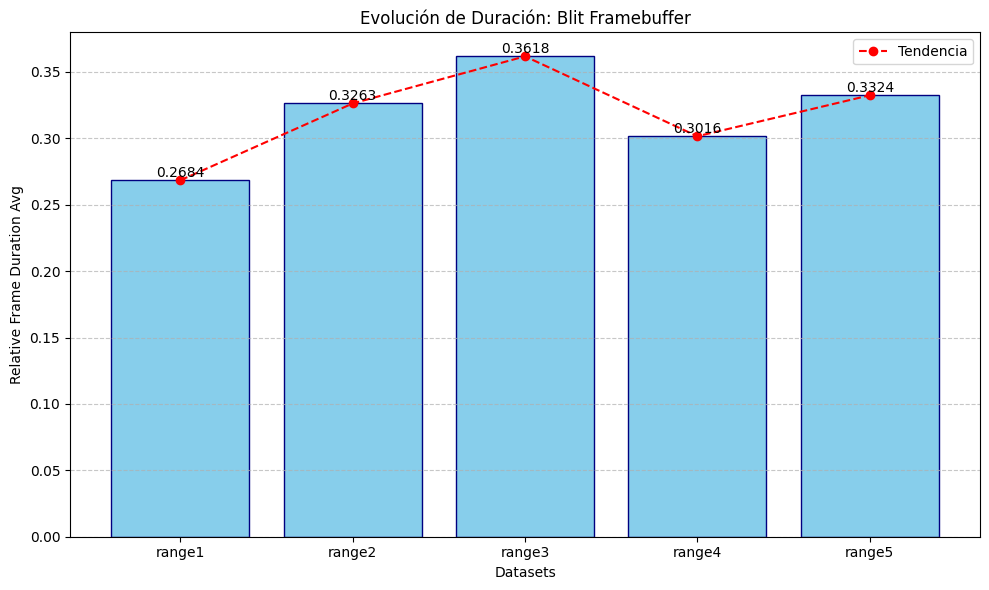

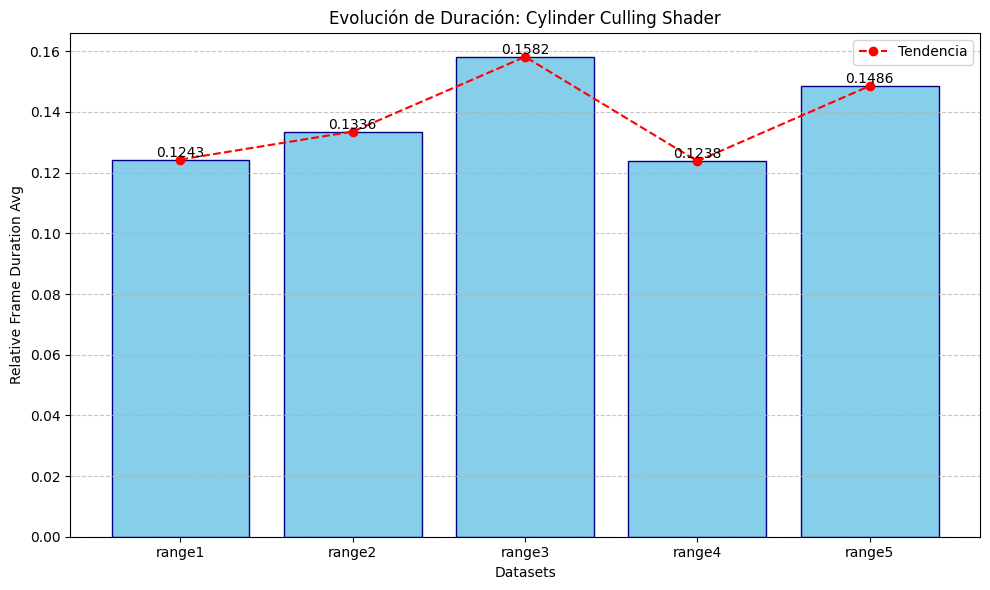

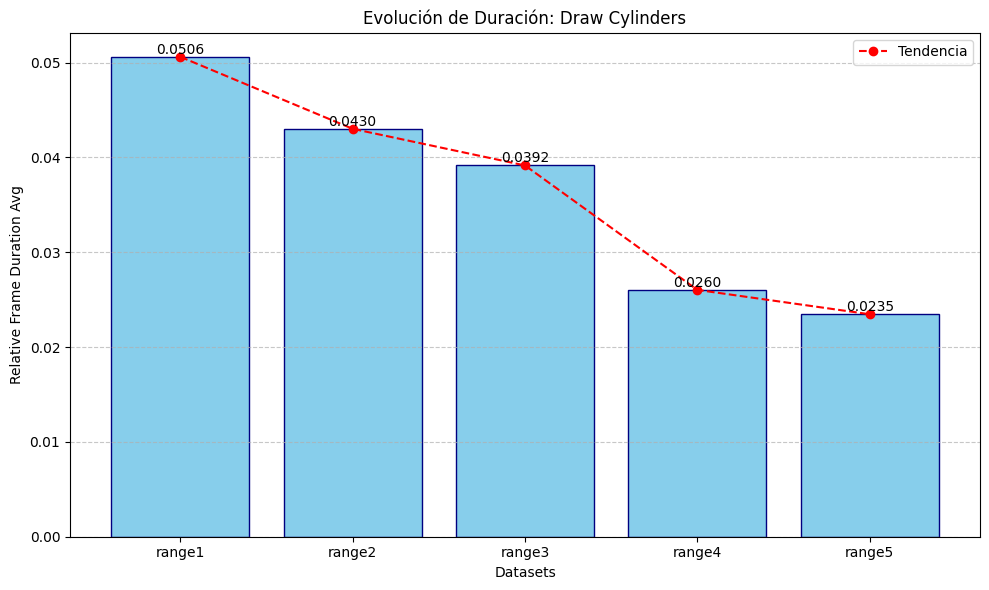

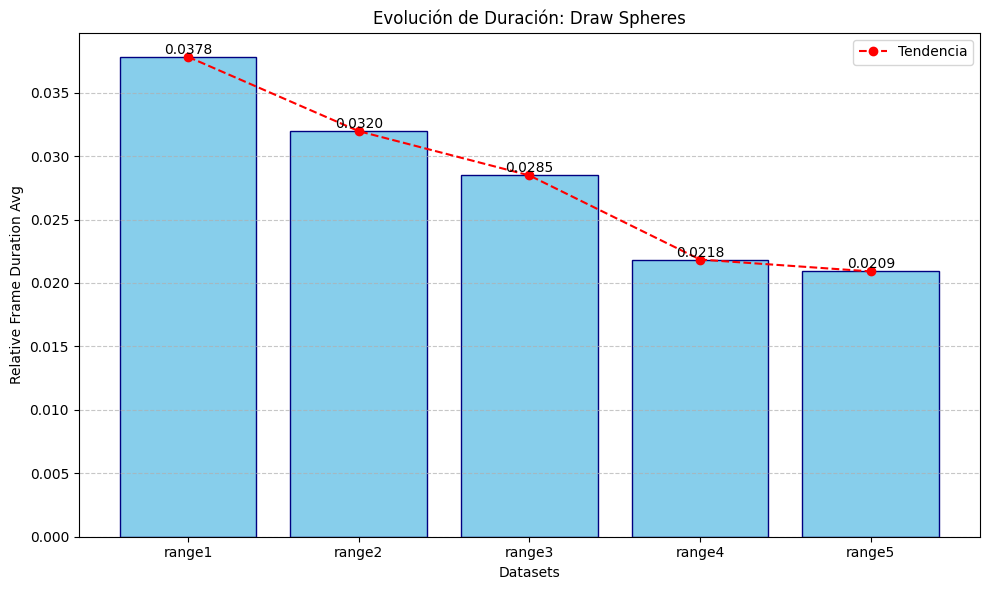

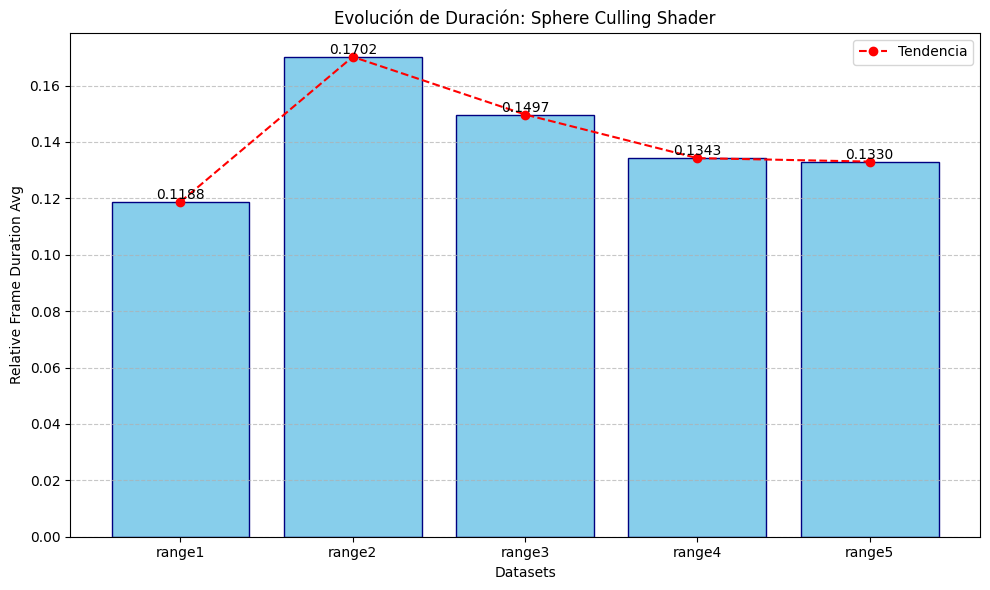

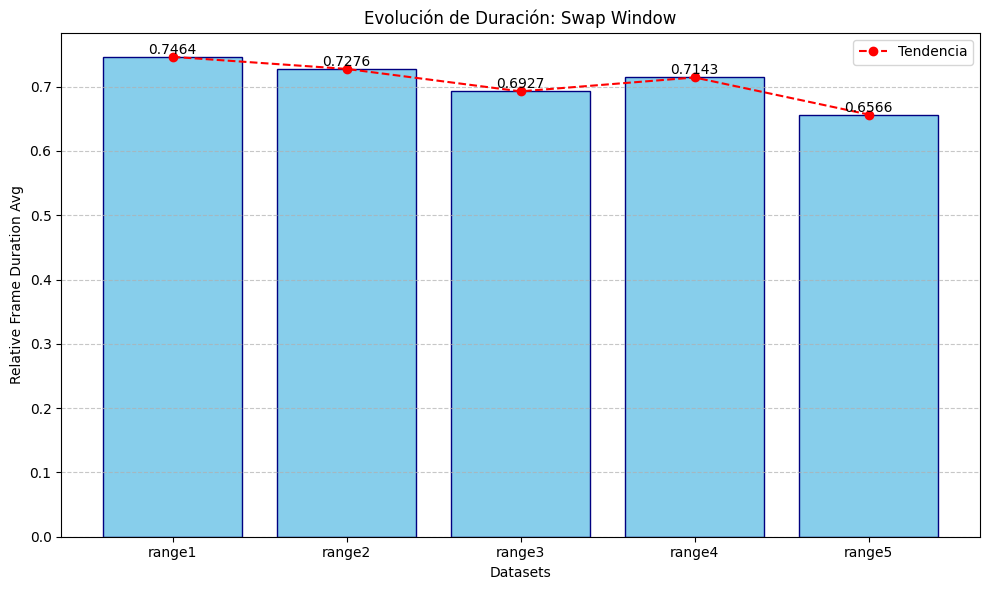

In [63]:
if 'cs_std_1aga_ranges' in locals() and cs_std_1aga_ranges:
    plotear_resultados_por_rango(cs_std_1aga_ranges, etiquetas_x)
else:
    print("La variable 'cs_std_1aga_ranges' no está definida o está vacía.")

Se encontraron 6 tipos de rangos para graficar: ['Blit Framebuffer', 'Cylinder Culling Shader', 'Draw Cylinders', 'Draw Spheres', 'Sphere Culling Shader', 'Swap Window']


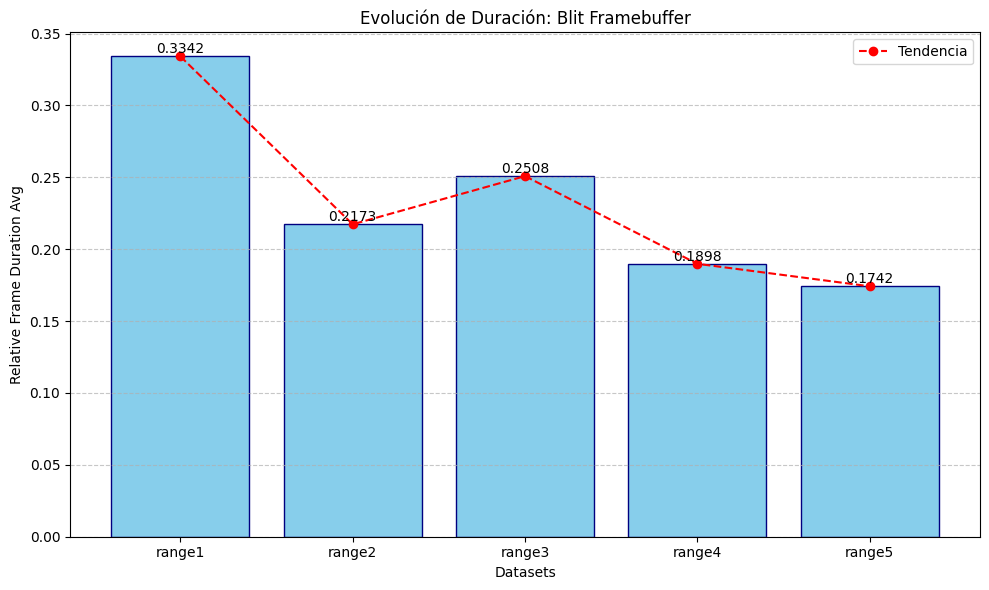

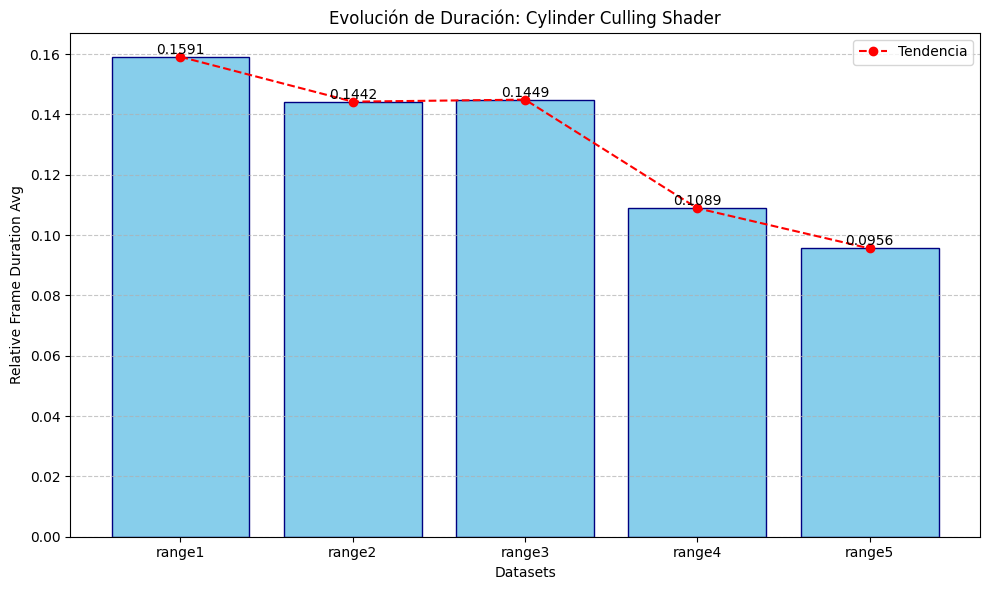

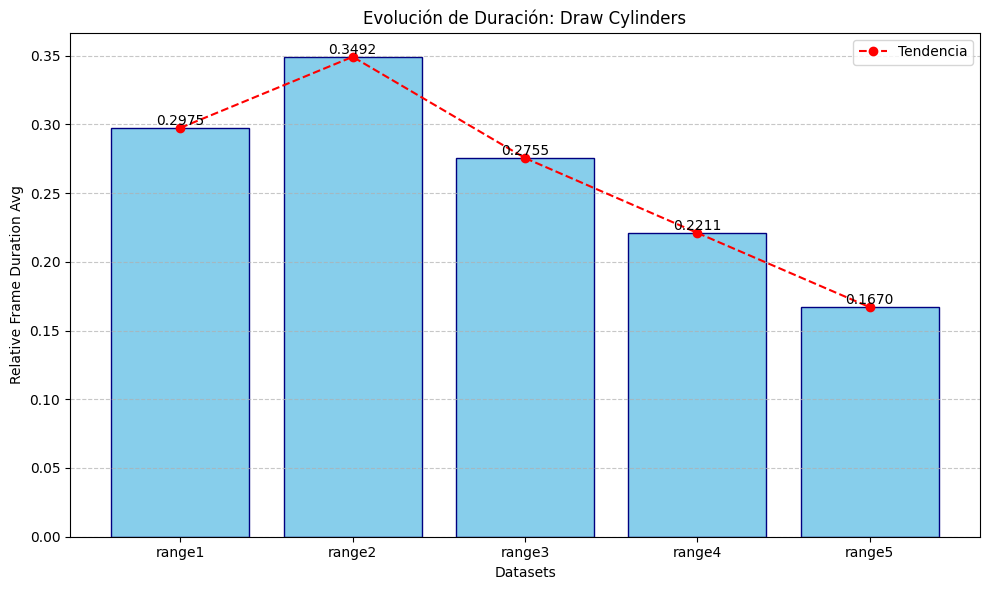

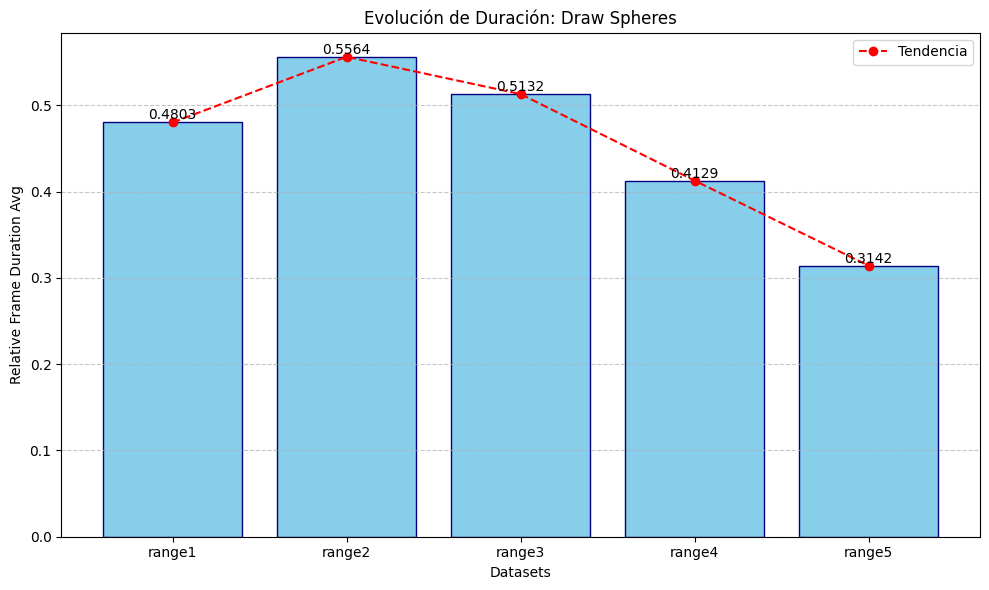

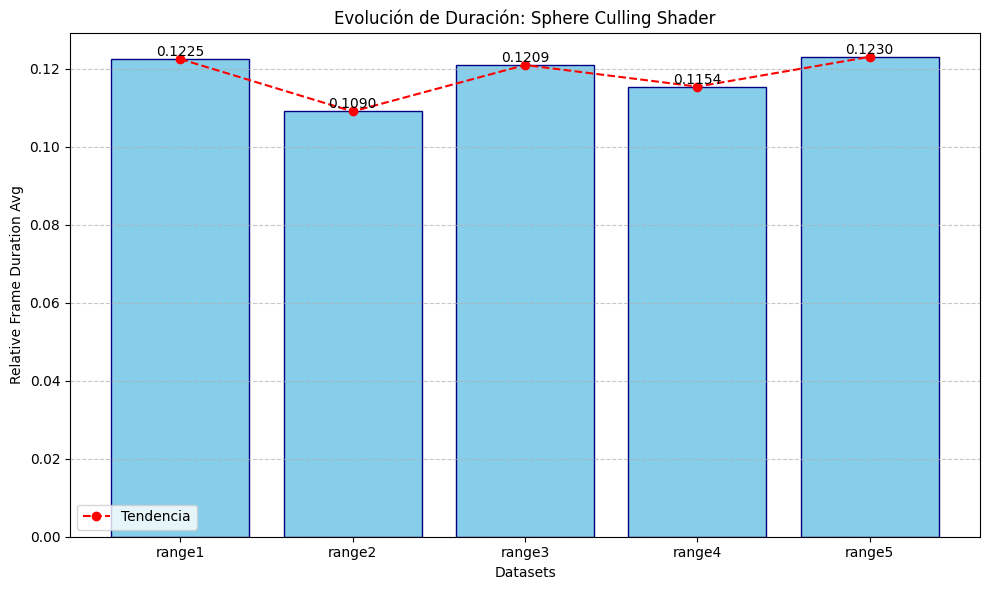

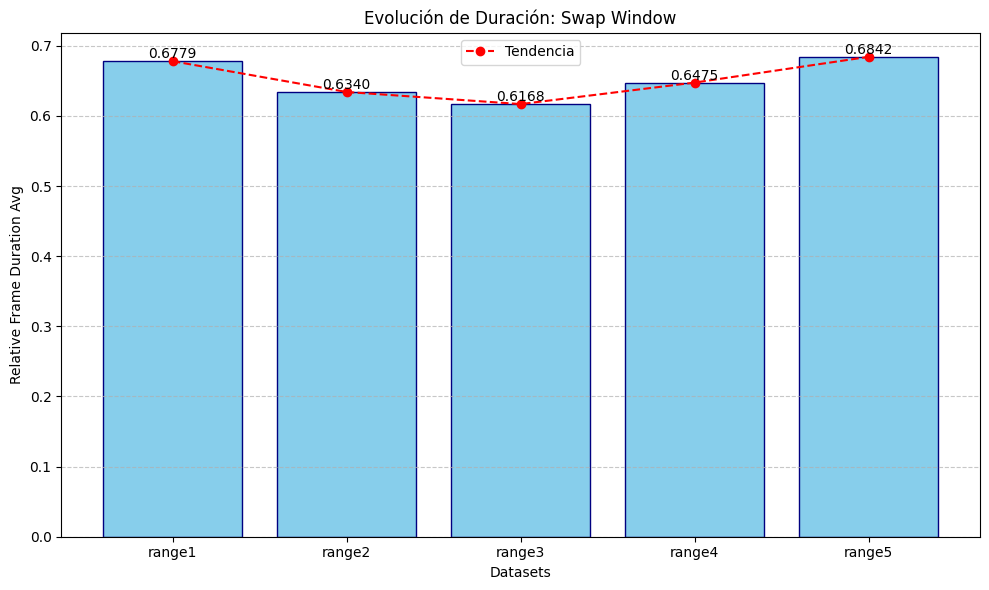

In [64]:
if 'cs_std_1c0o_ranges' in locals() and cs_std_1c0o_ranges:
    plotear_resultados_por_rango(cs_std_1c0o_ranges, etiquetas_x)
else:
    print("La variable 'cs_std_1c0o_ranges' no está definida o está vacía.")

Se encontraron 6 tipos de rangos para graficar: ['Blit Framebuffer', 'Cylinder Culling Shader', 'Draw Cylinders', 'Draw Spheres', 'Sphere Culling Shader', 'Swap Window']


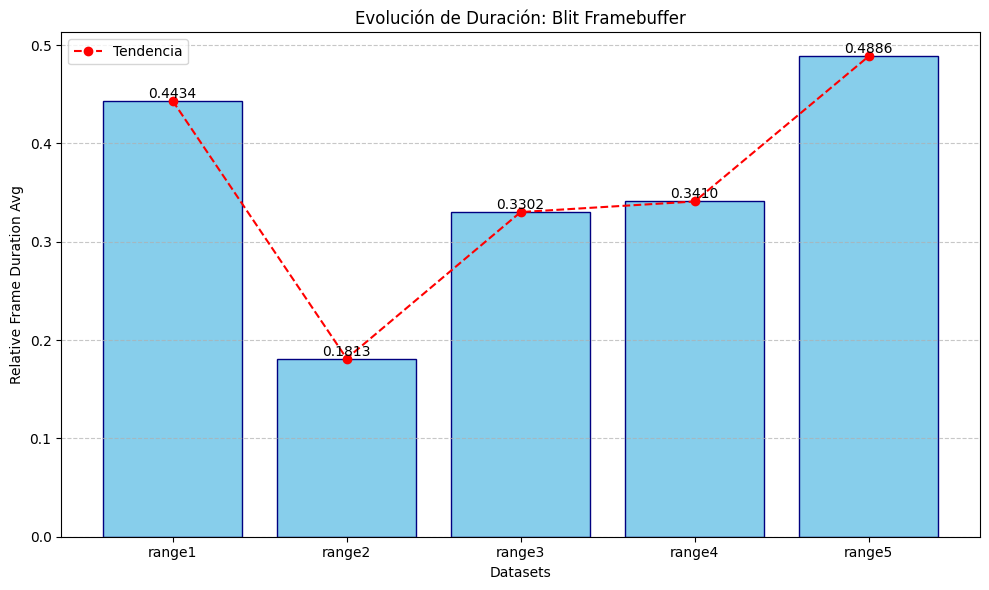

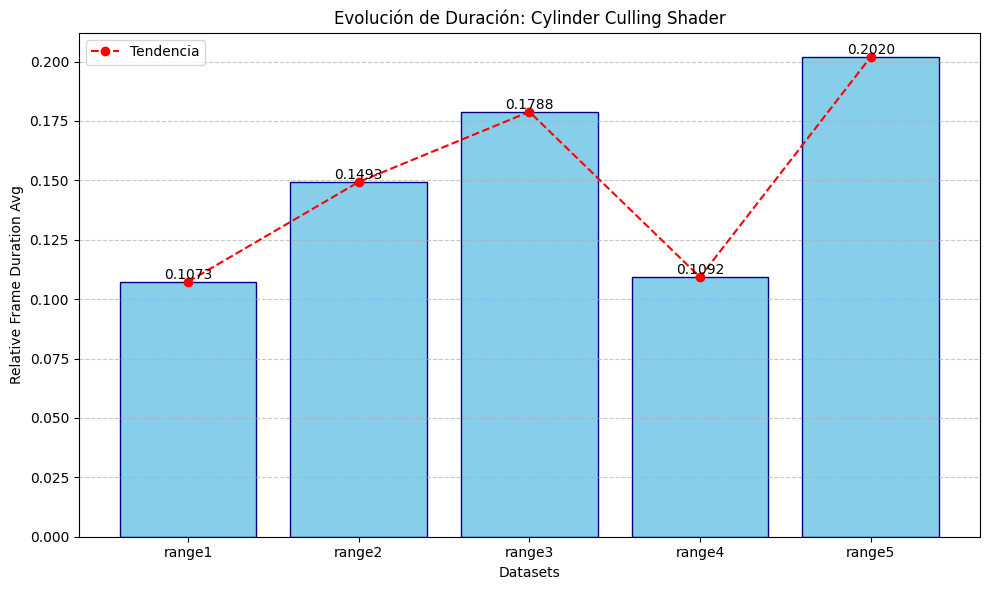

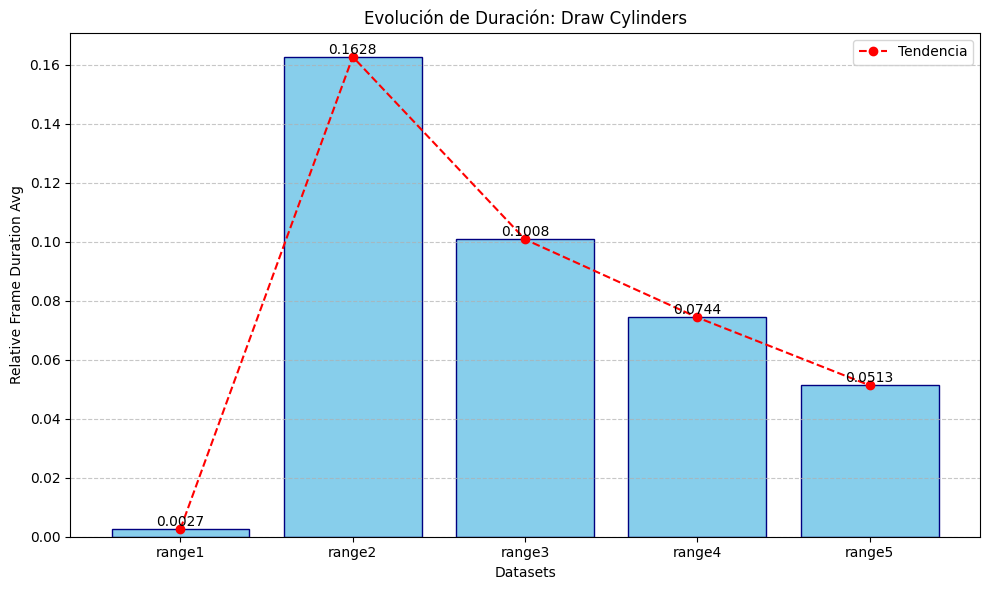

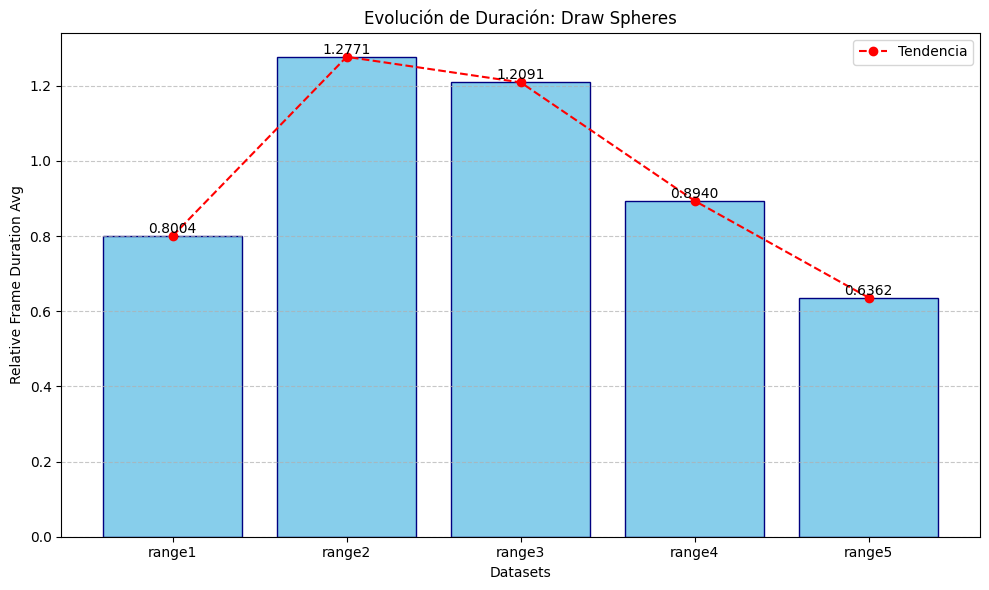

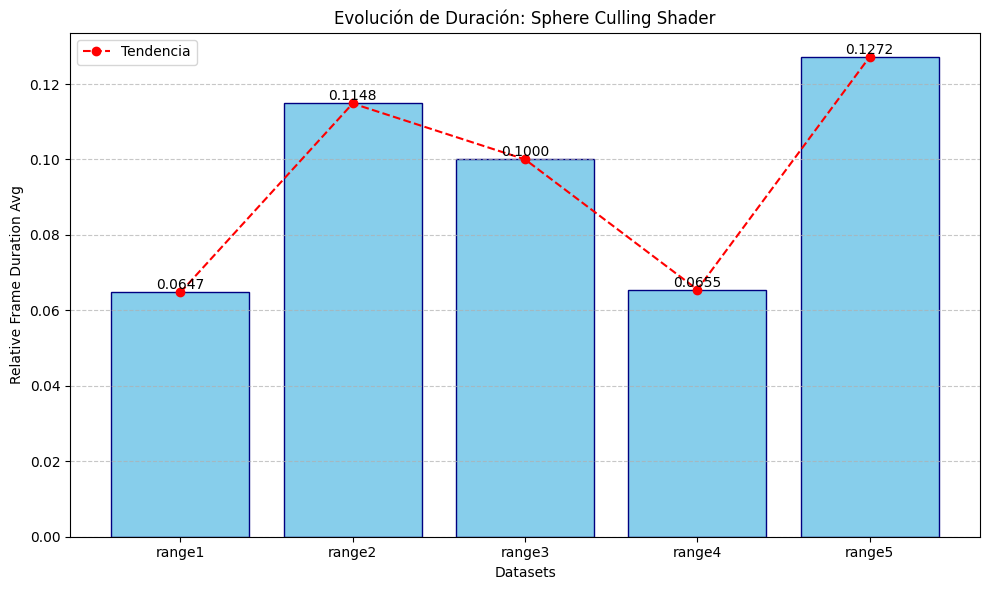

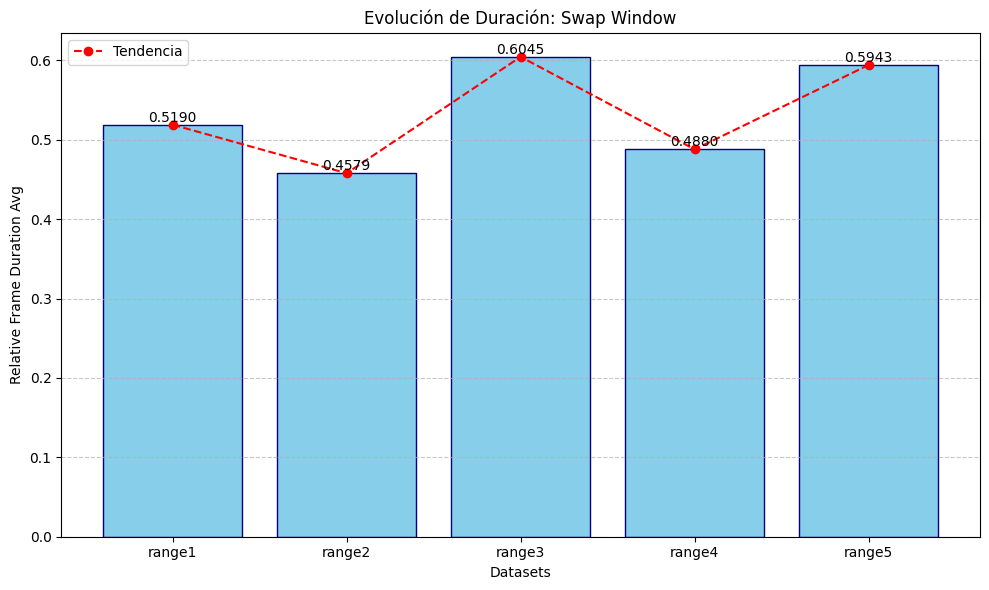

In [65]:
if 'cs_std_2mjq_ranges' in locals() and cs_std_2mjq_ranges:
    plotear_resultados_por_rango(cs_std_2mjq_ranges, etiquetas_x)
else:
    print("La variable 'cs_std_2mjq_ranges' no está definida o está vacía.")

Se encontraron 6 tipos de rangos para graficar: ['Blit Framebuffer', 'Cylinder Culling Shader', 'Draw Cylinders', 'Draw Spheres', 'Sphere Culling Shader', 'Swap Window']


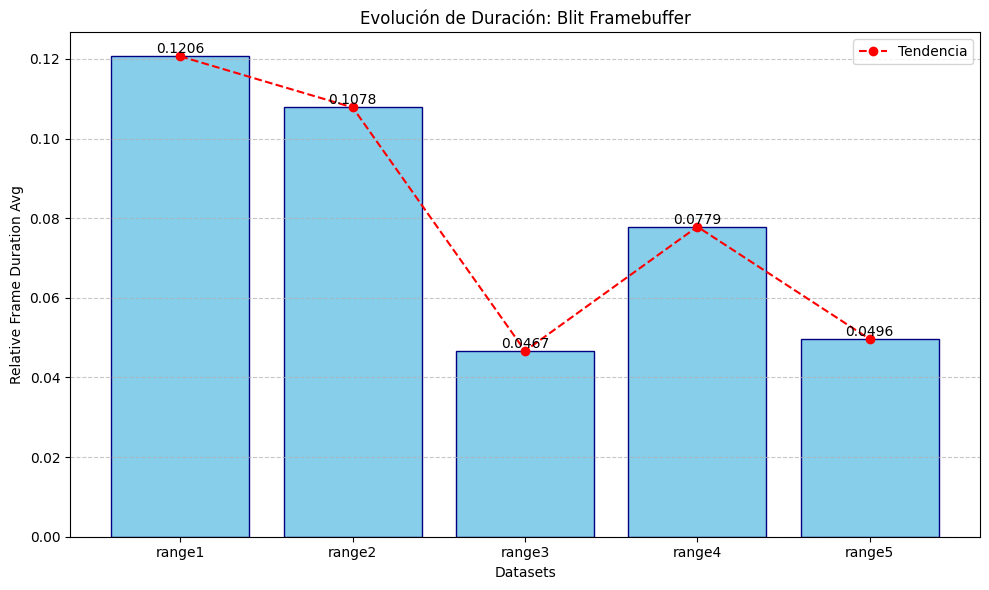

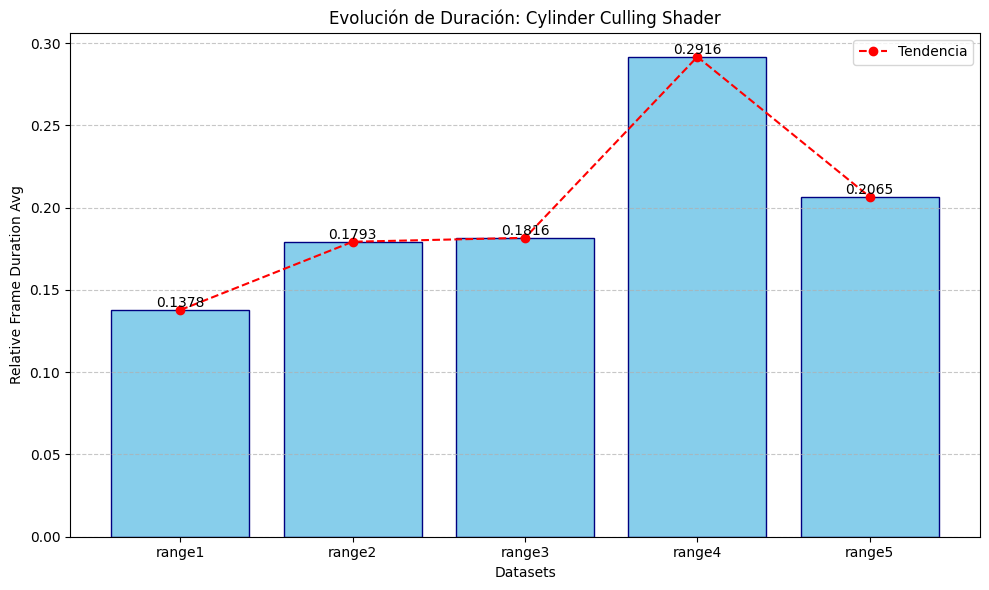

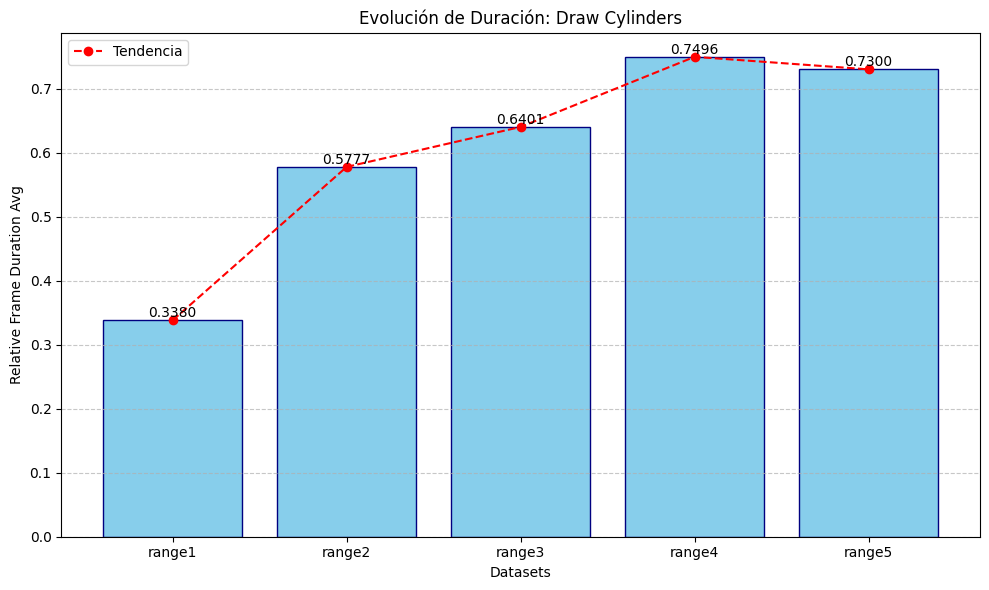

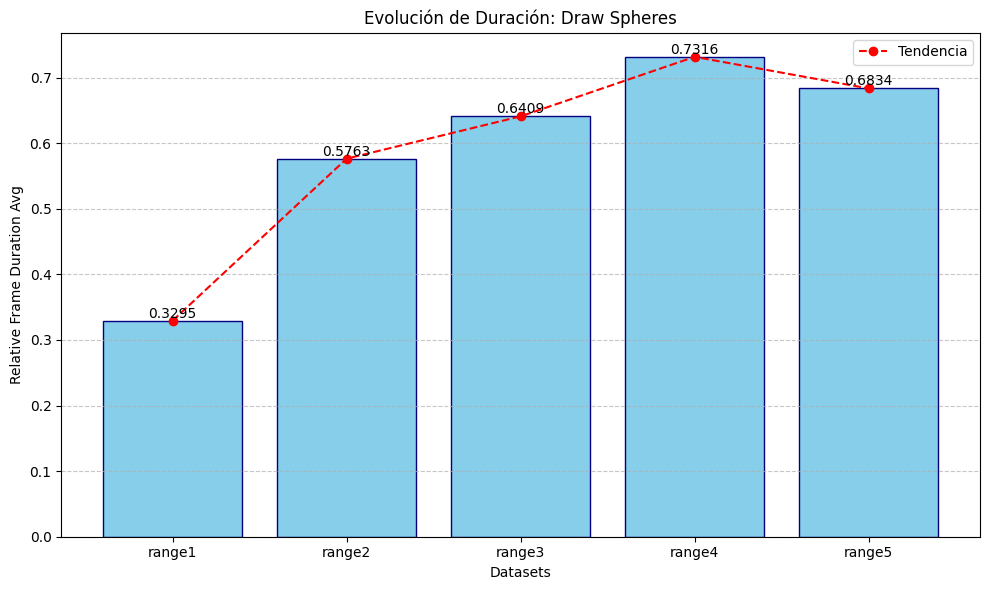

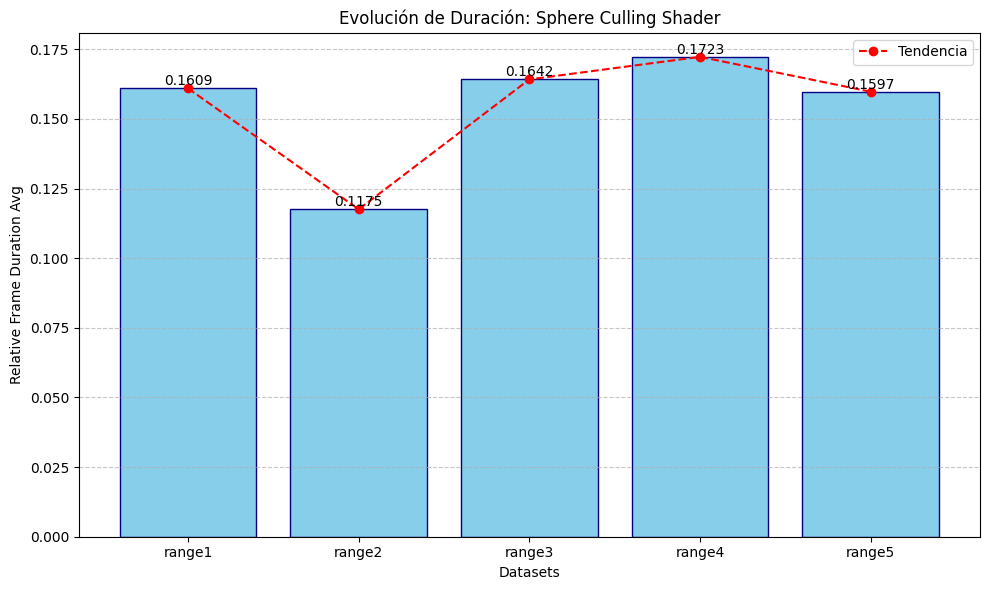

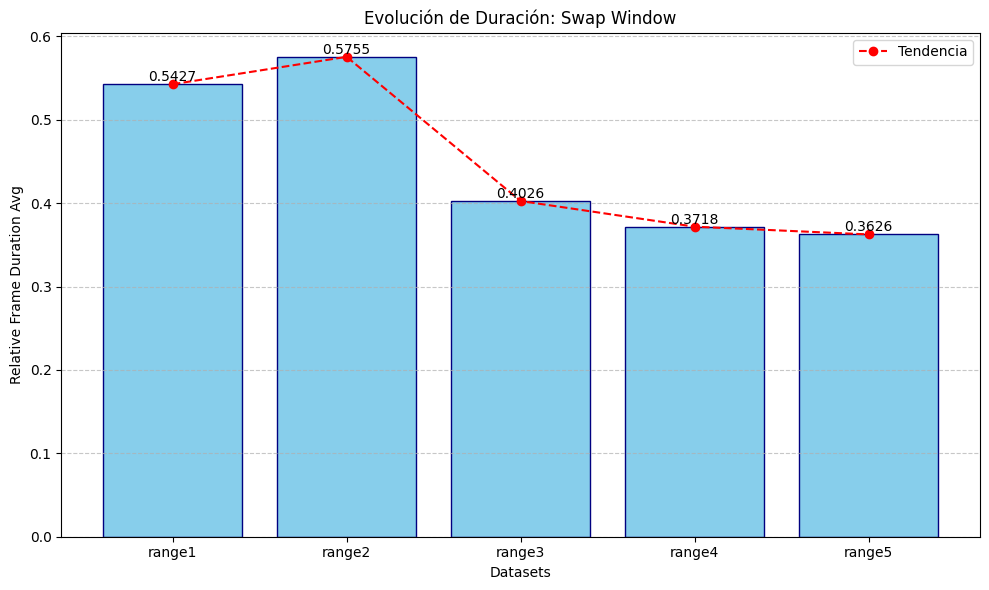

In [66]:
if 'cs_std_8wql_ranges' in locals() and cs_std_8wql_ranges:
    plotear_resultados_por_rango(cs_std_8wql_ranges, etiquetas_x)
else:
    print("La variable 'cs_std_8wql_ranges' no está definida o está vacía.")

In [ ]:
# --- EXTENSIÓN: ANÁLISIS AVANZADO CON PANDAS ---

def consolidar_datos_en_dataframe(diccionario_datos_cargados):
    """
    Transforma tu estructura de listas/diccionarios en un DataFrame único.
    diccionario_datos_cargados: Un dict donde la clave es el nombre del experimento
    (ej: "CS_1st_1aga") y el valor es la lista de rangos [range1, range2...]
    """
    filas = []
    
    for nombre_experimento, lista_rangos in diccionario_datos_cargados.items():
        # Parseamos el nombre (ej: CS_1st_1aga -> Version: CS_1st, Molecula: 1aga)
        # Ajusta esto según cómo nombres tus claves
        partes = nombre_experimento.split('_')
        version = f"{partes[0]}_{partes[1]}" if len(partes) >= 2 else "Desconocida"
        molecula = partes[2] if len(partes) >= 3 else "Desconocida"

        for i, datos_rango in enumerate(lista_rangos):
            nombre_dataset = f"range{i+1}"
            
            # datos_rango es una lista de diccionarios (uno por cada Shader/Range encontrado)
            for item in datos_rango:
                filas.append({
                    'Experimento': nombre_experimento,
                    'Version': version,
                    'Molecula': molecula,
                    'Dataset': nombre_dataset,
                    'Shader_Name': item.get('Range', 'Unknown'),
                    'Duration_ms': item.get('Real_Duration_ms_Avg', 0),
                    'Rel_Duration': item.get('RelativeFrameDuration_Avg', 0),
                    'Muestras': item.get('Total_Muestras', 0)
                })

    return pd.DataFrame(filas)



✅ DataFrame creado con 100 filas.


,Experimento,Version,Molecula,Dataset,Shader_Name,Duration_ms,Rel_Duration,Muestras
0,CS_1st_1aga,CS_1st,1aga,range1,Cleaning Shader,0.579859,0.004461,45
1,CS_1st_1aga,CS_1st,1aga,range1,Sphere Shader,81.240052,0.465302,45
2,CS_1st_1aga,CS_1st,1aga,range1,Cylinder Shader,84.004907,0.529731,45
3,CS_1st_1aga,CS_1st,1aga,range1,Blit Framebuffer,0.040665,0.000326,45
4,CS_1st_1aga,CS_1st,1aga,range1,Swap Window,0.017773,0.000152,45


In [ ]:
# --- USO ---
# 1. Agrupamos tus variables actuales en un diccionario
# (Asegúrate de que estas variables existen en tu entorno)
datos_para_analisis = {
    "CS_1st_1aga": cs_1st_1aga_ranges,
    "CS_1st_1c0o": cs_1st_1c0o_ranges,
    "CS_1st_2mjq": cs_1st_2mjq_ranges,
    "CS_1st_8wql": cs_1st_8wql_ranges
}

# 2. Creamos el DataFrame
df_cs_1st_master = consolidar_datos_en_dataframe(datos_para_analisis)

# Verificamos
print(f"✅ DataFrame creado con {len(df_cs_1st_master)} filas.")
display(df_cs_1st_master.head())


Top 5 Shaders más costosos (Promedio por llamada):


,mean,sum,count
Shader_Name,,,
Sphere Shader,19.687656,393.753129,20
Cylinder Shader,14.087998,281.759966,20
Cleaning Shader,0.428831,8.576627,20
Swap Window,0.139639,2.792771,20
Blit Framebuffer,0.066144,1.322881,20


C:\Users\Sebatian\AppData\Local\Temp\ipykernel_28708\617488263.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_shaders.head(10).index, y=top_shaders.head(10)['mean'], palette='viridis')


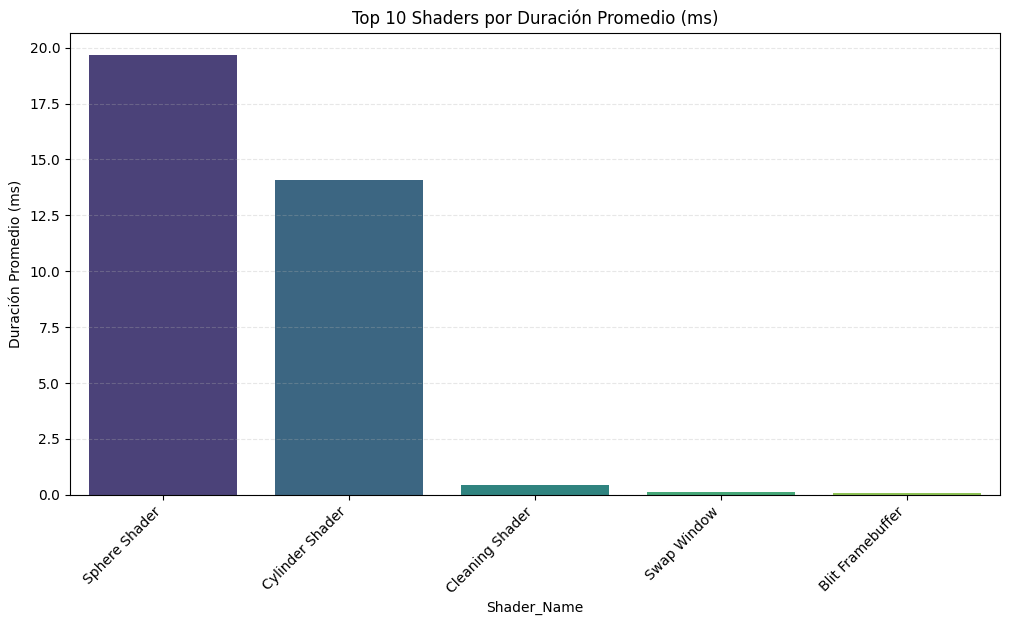

In [74]:
# Agrupar por Shader y calcular tiempo promedio y total
top_shaders = df_cs_1st_master.groupby('Shader_Name')['Duration_ms'].agg(['mean', 'sum', 'count']).sort_values(by='mean', ascending=False)

print("\nTop 5 Shaders más costosos (Promedio por llamada):")
display(top_shaders.head(5))

# Gráfico
plt.figure(figsize=(12, 6))
sns.barplot(x=top_shaders.head(10).index, y=top_shaders.head(10)['mean'], palette='viridis')
plt.title('Top 10 Shaders por Duración Promedio (ms)')
plt.ylabel('Duración Promedio (ms)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

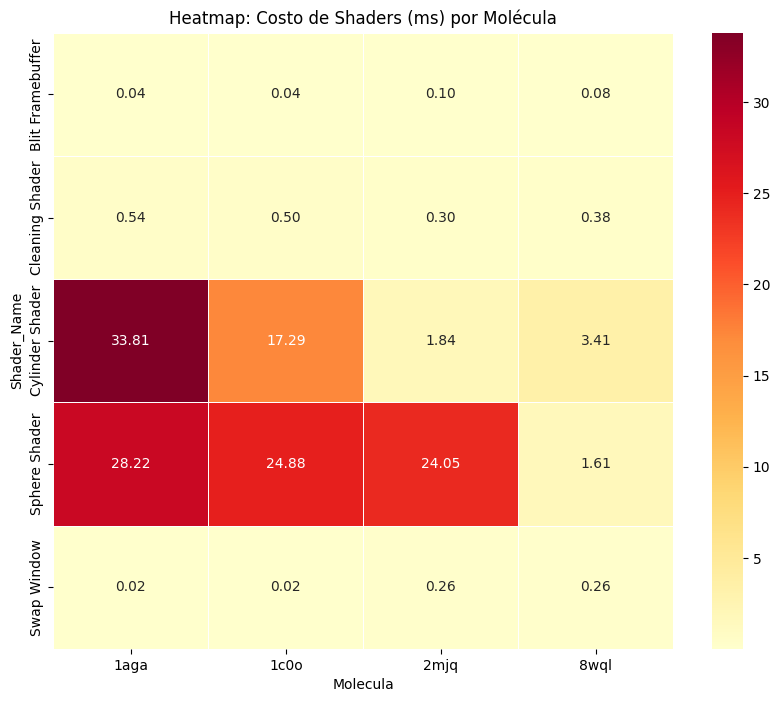

In [75]:
# Pivotar datos: Filas=Shaders, Columnas=Molecula, Valor=Duración
heatmap_data = df_cs_1st_master.pivot_table(index='Shader_Name', columns='Molecula', values='Duration_ms', aggfunc='mean')

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=.5)
plt.title('Heatmap: Costo de Shaders (ms) por Molécula')
plt.show()

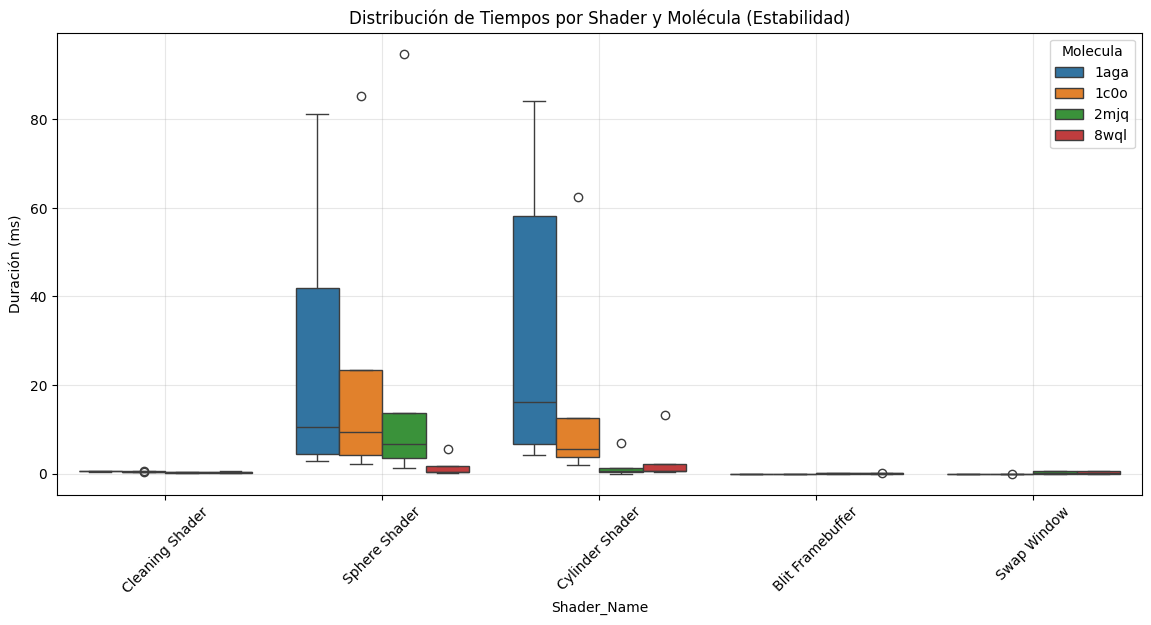

In [76]:
plt.figure(figsize=(14, 6))
# Filtramos solo los shaders principales para no saturar el gráfico
top_n_shaders = df_cs_1st_master.groupby('Shader_Name')['Duration_ms'].sum().nlargest(5).index
df_filtered = df_cs_1st_master[df_cs_1st_master['Shader_Name'].isin(top_n_shaders)]

sns.boxplot(data=df_filtered, x='Shader_Name', y='Duration_ms', hue='Molecula')
plt.title('Distribución de Tiempos por Shader y Molécula (Estabilidad)')
plt.xticks(rotation=45)
plt.ylabel('Duración (ms)')
plt.grid(True, alpha=0.3)
plt.show()

In [77]:
# --- USO ---
# 1. Agrupamos tus variables actuales en un diccionario
# (Asegúrate de que estas variables existen en tu entorno)
datos_para_analisis = {
    "CS_2nd_1aga": cs_2nd_1aga_ranges,
    "CS_2nd_1c0o": cs_2nd_1c0o_ranges,
    "CS_2nd_2mjq": cs_2nd_2mjq_ranges
}

# 2. Creamos el DataFrame
df_cs_2nd_master = consolidar_datos_en_dataframe(datos_para_analisis)

# Verificamos
print(f"✅ DataFrame creado con {len(df_cs_2nd_master)} filas.")
display(df_cs_2nd_master.head())

✅ DataFrame creado con 91 filas.


,Experimento,Version,Molecula,Dataset,Shader_Name,Duration_ms,Rel_Duration,Muestras
0,CS_2nd_1aga,CS_2nd,1aga,range1,Cleaning Shader,0.360348,0.222700,45
1,CS_2nd_1aga,CS_2nd,1aga,range1,Sphere Bbox Extraction Shader,0.010510,0.005972,45
2,CS_2nd_1aga,CS_2nd,1aga,range1,Sphere Bbox Intersection Shader,0.264692,0.159438,45
3,CS_2nd_1aga,CS_2nd,1aga,range1,Cylinder Bbox Extraction Shader,0.012288,0.007022,45
4,CS_2nd_1aga,CS_2nd,1aga,range1,Cylinder Bbox Intersection Shader,0.939852,0.557683,45


In [78]:
# --- USO ---
# 1. Agrupamos tus variables actuales en un diccionario
# (Asegúrate de que estas variables existen en tu entorno)
datos_para_analisis = {
    "CS_std_1aga": cs_std_1aga_ranges,
    "CS_std_1c0o": cs_std_1c0o_ranges,
    "CS_std_2mjq": cs_std_2mjq_ranges,
    "CS_std_8wql": cs_std_8wql_ranges
}

# 2. Creamos el DataFrame
df_cs_std_master = consolidar_datos_en_dataframe(datos_para_analisis)

# Verificamos
print(f"✅ DataFrame creado con {len(df_cs_std_master)} filas.")
display(df_cs_std_master.head())

✅ DataFrame creado con 120 filas.


,Experimento,Version,Molecula,Dataset,Shader_Name,Duration_ms,Rel_Duration,Muestras
0,CS_std_1aga,CS_std,1aga,range1,Sphere Culling Shader,0.118783,0.077703,45
1,CS_std_1aga,CS_std,1aga,range1,Draw Spheres,0.037825,0.025232,45
2,CS_std_1aga,CS_std,1aga,range1,Cylinder Culling Shader,0.124316,0.082520,45
3,CS_std_1aga,CS_std,1aga,range1,Draw Cylinders,0.050614,0.035279,45
4,CS_std_1aga,CS_std,1aga,range1,Blit Framebuffer,0.268409,0.200543,45
